In [1]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib as mpl
from pathlib import Path
import astropy.units as u
from astropy.table import Table
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from astropy.coordinates import SkyCoord
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec

from myutils import all_utils as au



In [2]:
# Path plots
path_plots = "paper_plots/ocean/"
os.mkdir(path_plots) if not os.path.exists(path_plots) else None


In [3]:

df_header_list=[]
df_phot_list=[]
list_to_read = glob.glob("data/SIMS_KN_OCEAN_250_YDET/*/*PHOT.FITS.gz")
print(f"Found {len(list_to_read)} PHOT.FITS.gz files to read.")
for fphot in list_to_read:
    df_header_tmp, df_phot_tmp = au.read_fits(fphot, drop_separators=True)
    print(f"Reading {fphot} with length {len(df_phot_tmp)}")
    df_header_list.append(df_header_tmp)
    df_phot_list.append(df_phot_tmp)
df_header = pd.concat(df_header_list, ignore_index=True)
# Read all PHOT.FITS.gz files and concatenate them    
df_phot = pd.concat(df_phot_list, ignore_index=True)
print(f"Number of light curves: {len(df_header)}")
print(f"Number of photometric points: {df_phot.groupby('SNID').count()['MJD'].median()} +- {df_phot.groupby('SNID').count()['MJD'].std()}")

Found 40 PHOT.FITS.gz files to read.
Reading data/SIMS_KN_OCEAN_250_YDET/PIP_AMR_KN_OCEAN_LSST_KN_KASEN_NOHOST/PIP_AMR_KN_OCEAN_LSST_KN_5c695_NONIaMODEL00-0004_PHOT.FITS.gz with length 4817
Reading data/SIMS_KN_OCEAN_250_YDET/PIP_AMR_KN_OCEAN_LSST_KN_KASEN_NOHOST/PIP_AMR_KN_OCEAN_LSST_KN_5c695_NONIaMODEL00-0003_PHOT.FITS.gz with length 7218
Reading data/SIMS_KN_OCEAN_250_YDET/PIP_AMR_KN_OCEAN_LSST_KN_KASEN_NOHOST/PIP_AMR_KN_OCEAN_LSST_KN_5c695_NONIaMODEL00-0016_PHOT.FITS.gz with length 4314
Reading data/SIMS_KN_OCEAN_250_YDET/PIP_AMR_KN_OCEAN_LSST_KN_KASEN_NOHOST/PIP_AMR_KN_OCEAN_LSST_KN_5c695_NONIaMODEL00-0011_PHOT.FITS.gz with length 5123
Reading data/SIMS_KN_OCEAN_250_YDET/PIP_AMR_KN_OCEAN_LSST_KN_KASEN_NOHOST/PIP_AMR_KN_OCEAN_LSST_KN_5c695_NONIaMODEL00-0020_PHOT.FITS.gz with length 4516
Reading data/SIMS_KN_OCEAN_250_YDET/PIP_AMR_KN_OCEAN_LSST_KN_KASEN_NOHOST/PIP_AMR_KN_OCEAN_LSST_KN_5c695_NONIaMODEL00-0010_PHOT.FITS.gz with length 4359
Reading data/SIMS_KN_OCEAN_250_YDET/PIP_AMR_K

In [4]:
df_header.groupby('model_name').count()['SNID']

model_name
Bulla    4261
Kasen    4226
Name: SNID, dtype: int64

In [5]:
dic_gt5 = {}
for typ in df_header.SIM_GENTYPE.unique():
    
    # Select matching SNIDs from df_phot
    sel_snids = df_header[df_header.SIM_GENTYPE == typ].SNID
    print(f"\nNumber of light curves with SIM_GENTYPE = {typ} | {au.dic_sntype[str(typ)]}: {len(sel_snids)}")

    # Total SNIDs for this SIM_GENTYPE
    total_typ_snids = len(sel_snids)

    # Photometry
    sel = df_phot[df_phot.SNID.isin(sel_snids)]
    print(f"Number of photometric points for this type: {len(sel)}")

    # Compute SNR thresholds
    typ_str = au.dic_sntype[f"{typ}"]
    dic_gt5[typ_str] = sel[sel['SNR'] > 5]
    snr_gt_5 = dic_gt5[typ_str]['SNID'].nunique()
    snr_gt_3 = sel[sel['SNR'] > 3]['SNID'].nunique()

    # Group by SNID, count how many SNR > 5 measurements each has
    snr_gt5_counts = dic_gt5[typ_str].groupby('SNID').size()

    # Count how many SNIDs have at least two such measurements
    snr_gt5_atleast2 = (snr_gt5_counts >= 2).sum()

    # Group by SNID and check MJD separation
    def has_two_sep_days(group):
        mjds = group['MJD'].sort_values().values
        for i in range(len(mjds)):
            for j in range(i+1, len(mjds)):
                if abs(mjds[j] - mjds[i]) > 1:
                    return True
        return False

    # Apply the function to each group
    snids_with_two_sep_days = dic_gt5[typ_str].groupby('SNID').filter(has_two_sep_days)['SNID'].nunique()
    

    print(f"{snr_gt_5} light curves have 1 detection with SNR > 5 = {snr_gt_5 / total_typ_snids * 100:.2f}% of this type")
    print(f"{snr_gt5_atleast2} light curves have 2 detections with SNR > 5 = {snr_gt5_atleast2 / total_typ_snids * 100:.2f}% of this type")
    print(f"{snids_with_two_sep_days} light curves have 2 detections with SNR > 5 in >1 day = {snids_with_two_sep_days / total_typ_snids * 100:.2f}% of this type")

    print("")
    print(f"{snr_gt_3} light curves have 1 detection with SNR > 3 = {snr_gt_3 / total_typ_snids * 100:.2f}% of this type")



Number of light curves with SIM_GENTYPE = 50 | Kasen: 4226
Number of photometric points for this type: 97648
367 light curves have 1 detection with SNR > 5 = 8.68% of this type
217 light curves have 2 detections with SNR > 5 = 5.13% of this type
90 light curves have 2 detections with SNR > 5 in >1 day = 2.13% of this type

707 light curves have 1 detection with SNR > 3 = 16.73% of this type

Number of light curves with SIM_GENTYPE = 51 | Bulla: 4261
Number of photometric points for this type: 98727
511 light curves have 1 detection with SNR > 5 = 11.99% of this type
295 light curves have 2 detections with SNR > 5 = 6.92% of this type
69 light curves have 2 detections with SNR > 5 in >1 day = 1.62% of this type

893 light curves have 1 detection with SNR > 3 = 20.96% of this type


In [6]:
for typ in dic_gt5.keys():
    # Count number of rows with SNR > 5 per BAND
    snr_gt5_by_band = dic_gt5[typ_str].groupby('BAND').size()

    # Find the BAND with the most such entries
    most_common_band = snr_gt5_by_band.idxmax()
    count_most_common_band = snr_gt5_by_band.max()
    print(f"{typ}: The most common BAND with SNR > 5 is {most_common_band} with {count_most_common_band} entries.")
    print(snr_gt5_by_band)
# Combine SNIDs from both models
snids_all_snr_gt5 = np.concatenate([
    dic_gt5['Bulla'].SNID.values, 
    dic_gt5['Kasen'].SNID.values
])

Kasen: The most common BAND with SNR > 5 is LSST-i with 400 entries.
BAND
LSST-Y    119
LSST-g     82
LSST-i    400
LSST-r    314
LSST-u      6
LSST-z    237
dtype: int64
Bulla: The most common BAND with SNR > 5 is LSST-i with 400 entries.
BAND
LSST-Y    119
LSST-g     82
LSST-i    400
LSST-r    314
LSST-u      6
LSST-z    237
dtype: int64


/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_88356/295937757.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  snids_count_sep_days = dic_gt5[typ].groupby('SNID').apply(lambda x: delta_days(x))
/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_88356/295937757.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  snids_count_sep_days = dic_gt5[typ].groupby('SNID').apply(lambda x: delta_days(x))


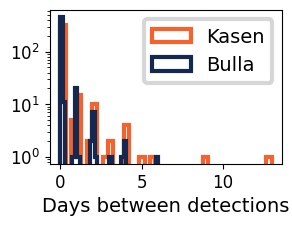

In [7]:
def delta_days(group):
    mjds = group['MJD'].sort_values().values
    for i in range(len(mjds)):
        for j in range(i+1, len(mjds)):
            return mjds[j] - mjds[i]
    return 0
fig = plt.figure(figsize=(3, 2))
for typ in dic_gt5.keys():
    snids_count_sep_days = dic_gt5[typ].groupby('SNID').apply(lambda x: delta_days(x))
    plt.hist(snids_count_sep_days, bins=40, histtype='step',label=typ,color=au.dic_KN_models_colors[typ])
plt.yscale('log')
plt.xlabel('Days between detections')
plt.legend()

Text(0.5, 0, 'Simulated redshift')

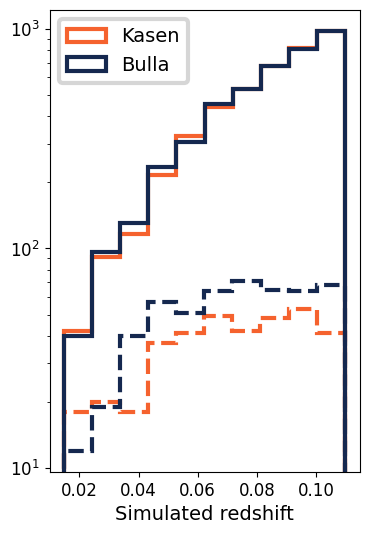

In [8]:
fig = plt.figure(figsize=(4,6))
color_list = ['blue','orange']
for m, model in enumerate(df_header.model_name.unique()):
    sel = df_header[df_header.model_name == model]
    plt.hist(sel['SIM_REDSHIFT_CMB'], label=model, histtype='step', color= au.dic_KN_models_colors[model])
    # SNR>5
    sel = sel[sel.SNID.isin(snids_all_snr_gt5)]
    plt.hist(sel['SIM_REDSHIFT_CMB'], histtype='step', color= au.dic_KN_models_colors[model], linestyle='dashed')
plt.legend()
plt.yscale('log')
plt.xlabel('Simulated redshift')

/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_88356/1287723942.py:28: RuntimeWarning: invalid value encountered in divide
  efficiency = counts_snr / counts_sim
/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_88356/1287723942.py:30: RuntimeWarning: invalid value encountered in divide
  err_efficiency = np.sqrt((err_data / counts_snr) ** 2 +
/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_88356/1287723942.py:31: RuntimeWarning: invalid value encountered in divide
  (err_sim / counts_sim) ** 2) * efficiency


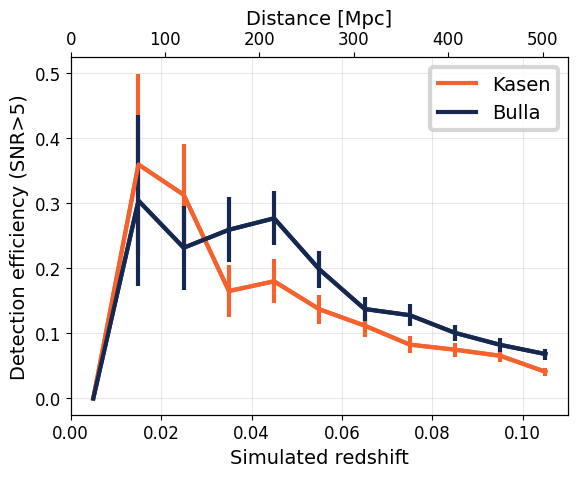

In [9]:
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo
import numpy as np

fig = plt.figure(figsize=(6,5))
ax = plt.gca()
color_list = ['blue', 'orange']

# Define redshift bins
bins = np.linspace(0, max(df_header['SIM_REDSHIFT_CMB']), 12)
bin_centers = 0.5 * (bins[1:] + bins[:-1])

for m, model in enumerate(df_header.model_name.unique()):
    sel = df_header[df_header.model_name == model]
    
    # All events
    counts_sim, _ = np.histogram(sel['SIM_REDSHIFT_CMB'], bins=bins)
    
    # Events with SNR > 5
    sel_snr = sel[sel.SNID.isin(snids_all_snr_gt5)]
    counts_snr, _ = np.histogram(sel_snr['SIM_REDSHIFT_CMB'], bins=bins)

    # add errors
    err_data = np.sqrt(counts_snr)
    err_sim = np.sqrt(counts_sim)
    
    # Efficiency = fraction
    efficiency = counts_snr / counts_sim
    efficiency[np.isnan(efficiency)] = 0  # Handle empty bins
    err_efficiency = np.sqrt((err_data / counts_snr) ** 2 +
                             (err_sim / counts_sim) ** 2) * efficiency
    err_efficiency = np.nan_to_num(err_efficiency)
    
    ax.plot(bin_centers, efficiency, color=au.dic_KN_models_colors[model], label=model)
    ax.errorbar(bin_centers, efficiency, yerr=err_efficiency, color=au.dic_KN_models_colors[model])

ax.set_xlabel('Simulated redshift')
ax.set_ylabel('Detection efficiency (SNR>5)')
ax.legend()
ax.grid(alpha=0.3)

# --- Add secondary x-axis for distance ---
def z_to_mpc(z):
    return cosmo.luminosity_distance(z).value  # in Mpc

ax2 = ax.twiny()
ax2.set_xlim(z_to_mpc(ax.get_xlim()[0]), z_to_mpc(ax.get_xlim()[1]))
ax2.set_xlabel('Distance [Mpc]')

plt.tight_layout()
plt.savefig(f'{path_plots}/efficiency_alert_vs_redshift.png')


### Rubin Deep Drilling Fields

In [10]:
# Calculate counts
count_ddf = df_header['in_ddf_field'].sum()
total_count = len(df_header)
total_selected = len(df_header[df_header.SNID.isin(snids_all_snr_gt5)])

print(
    f"# Lcs in DDF fields: {count_ddf} = "
    f"{np.round(count_ddf * 100 / total_count, 2)}% of all lcs = "
    f"{np.round(count_ddf * 100 / total_selected, 2)}% of all lcs SNR>5"
)
print("DDF fields with light curves:")
for field in au.ddf_fields['Field']:
    count = df_header[df_header['ddf_field_name'] == field].shape[0]
    print(f"{field}: {count} light curves")
# Save the header and photometry dataframes to CSV files

# Lcs in DDF fields: 32 = 0.38% of all lcs = 3.64% of all lcs SNR>5
DDF fields with light curves:
ELAISS1: 4 light curves
XMM_LSS: 4 light curves
ECDFS: 11 light curves
COSMOS: 6 light curves
EDFS_a: 3 light curves
EDFS_b: 4 light curves


/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_88356/3532982510.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


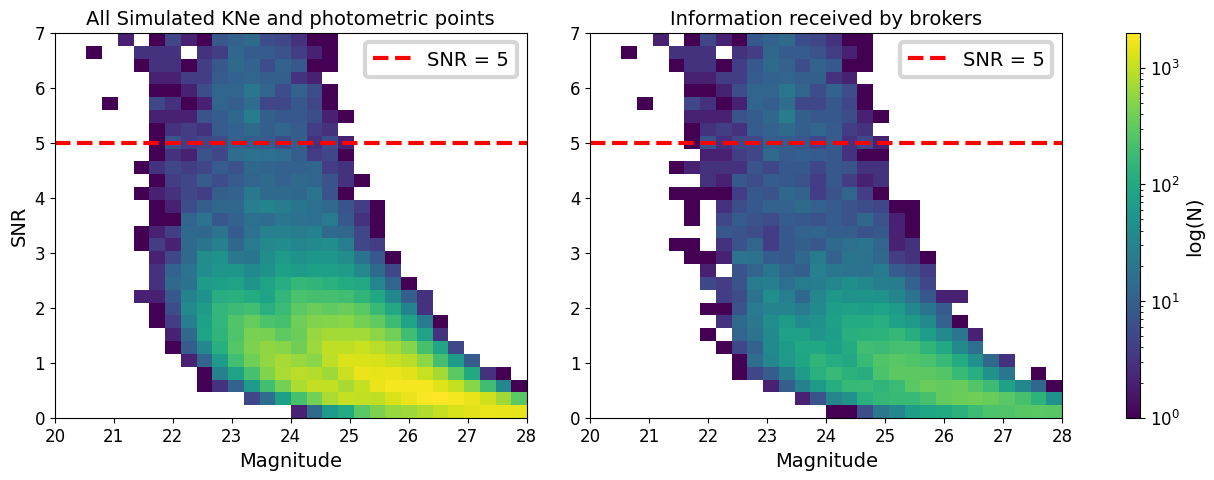

In [11]:
# SNR vs magnitude

# Define bins and ranges
x_bins = 30
y_bins = 30
x_range = [20, 28]
y_range = [0, 7]
bins = [x_bins, y_bins]
range_ = [x_range, y_range]

# Compute 2D histograms manually
H1, _, _ = np.histogram2d(df_phot['magnitude'], df_phot['SNR'],
                          bins=bins, range=range_)
H2, _, _ = np.histogram2d(df_phot[df_phot['SNID'].isin(snids_all_snr_gt5)]['magnitude'], df_phot[df_phot['SNID'].isin(snids_all_snr_gt5)]['SNR'],
                          bins=bins, range=range_)

# Determine global vmin and vmax for LogNorm (exclude zeros)
nonzero_counts = np.concatenate([H1.ravel(), H2.ravel()])
nonzero_counts = nonzero_counts[nonzero_counts > 0]
vmin = nonzero_counts.min()
vmax = nonzero_counts.max()

# Create figure with 3 subplots: 2 main plots + 1 thin colorbar subplot
fig = plt.figure(figsize=(14, 5))
gs = GridSpec(1, 3, width_ratios=[1, 1, 0.03], wspace=0.2)

# First heatmap (left)
ax1 = fig.add_subplot(gs[0])
im1 = ax1.imshow(H1.T, origin='lower',
                 extent=[*x_range, *y_range],
                 aspect='auto', cmap='viridis',
                 norm=LogNorm(vmin=vmin, vmax=vmax))
ax1.set_title('All Simulated KNe and photometric points')
ax1.set_xlabel('Magnitude')
ax1.set_ylabel('SNR')
ax1.axhline(y=5, color='r', linestyle='--', label='SNR = 5')
ax1.legend()

# Second heatmap (middle)
ax2 = fig.add_subplot(gs[1], sharey=ax1)
im2 = ax2.imshow(H2.T, origin='lower',
                 extent=[*x_range, *y_range],
                 aspect='auto', cmap='viridis',
                 norm=LogNorm(vmin=vmin, vmax=vmax))
ax2.set_title('Information received by brokers')
ax2.set_xlabel('Magnitude')
ax2.axhline(y=5, color='r', linestyle='--', label='SNR = 5')
ax2.legend()

# Colorbar subplot (right, very thin)
cax = fig.add_subplot(gs[2])
cbar = fig.colorbar(im2, cax=cax)
cbar.set_label('log(N)')

plt.tight_layout()
plt.show()


# With Alert in broker

/Users/amoller/Science/KN_OzGrav/KNcand_LVK/Rubin_KNe_with_Fink_LVK/myutils/all_utils.py:589: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(second_alert_range)


SNID 30406_Bulla z=0.05
SNID 17164_Bulla z=0.03


/Users/amoller/Science/KN_OzGrav/KNcand_LVK/Rubin_KNe_with_Fink_LVK/myutils/all_utils.py:589: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(second_alert_range)
/Users/amoller/Science/KN_OzGrav/KNcand_LVK/Rubin_KNe_with_Fink_LVK/myutils/all_utils.py:589: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(second_alert_range)


SNID 16694_Bulla z=0.05
SNID 15424_Bulla z=0.07
SNID 10670_Bulla z=0.11


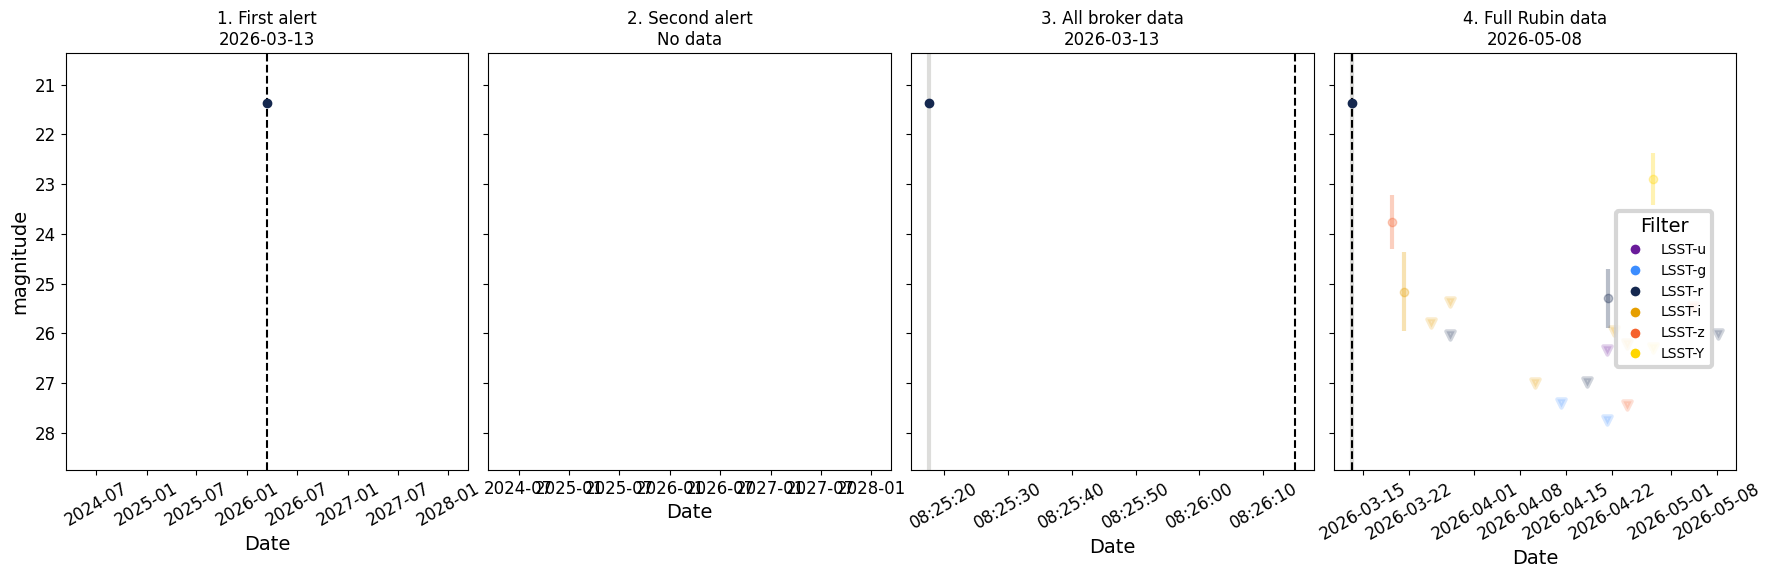

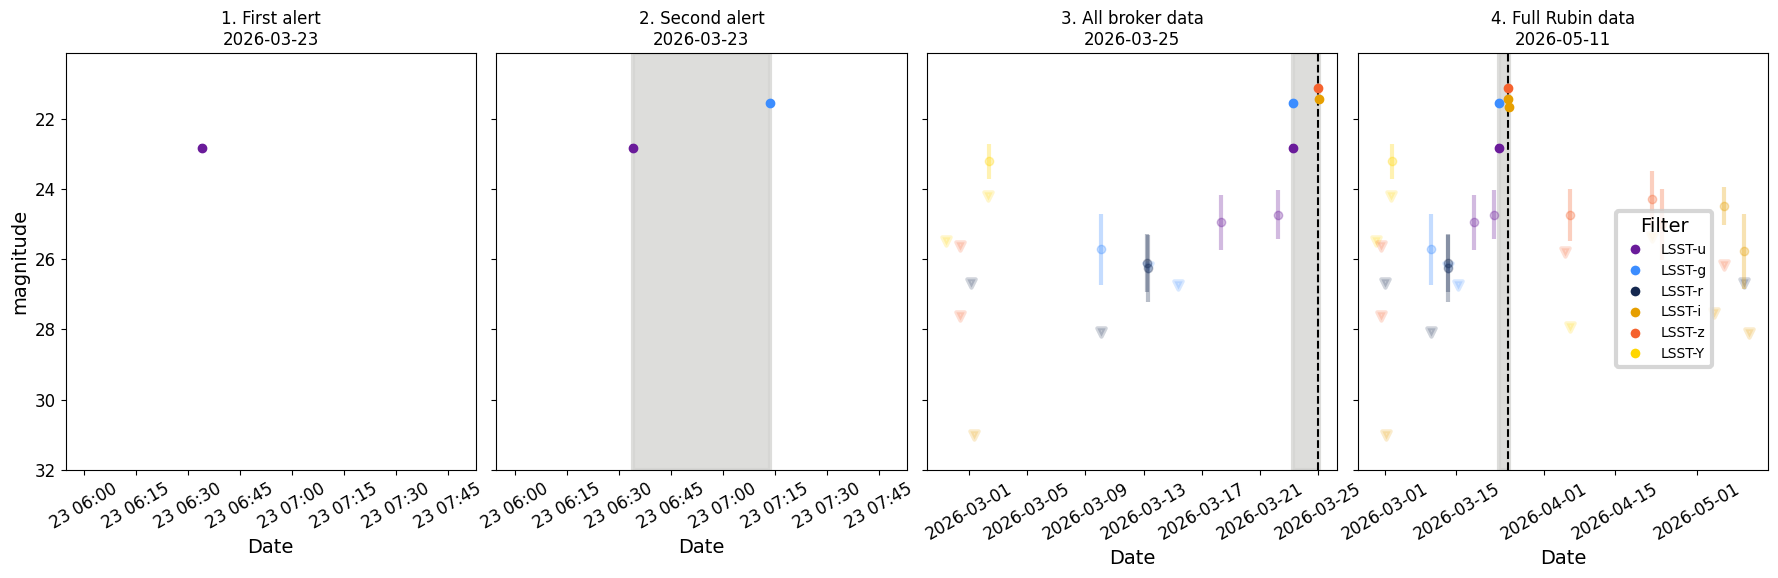

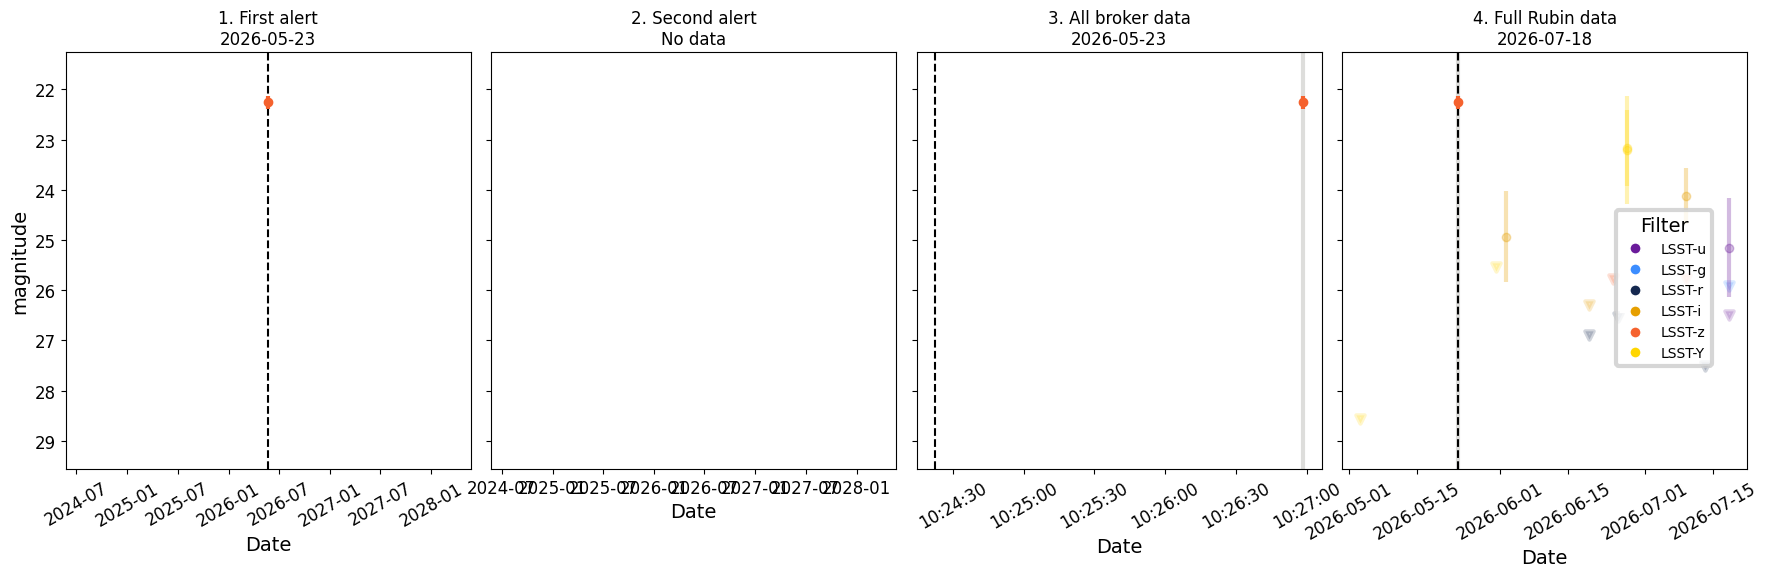

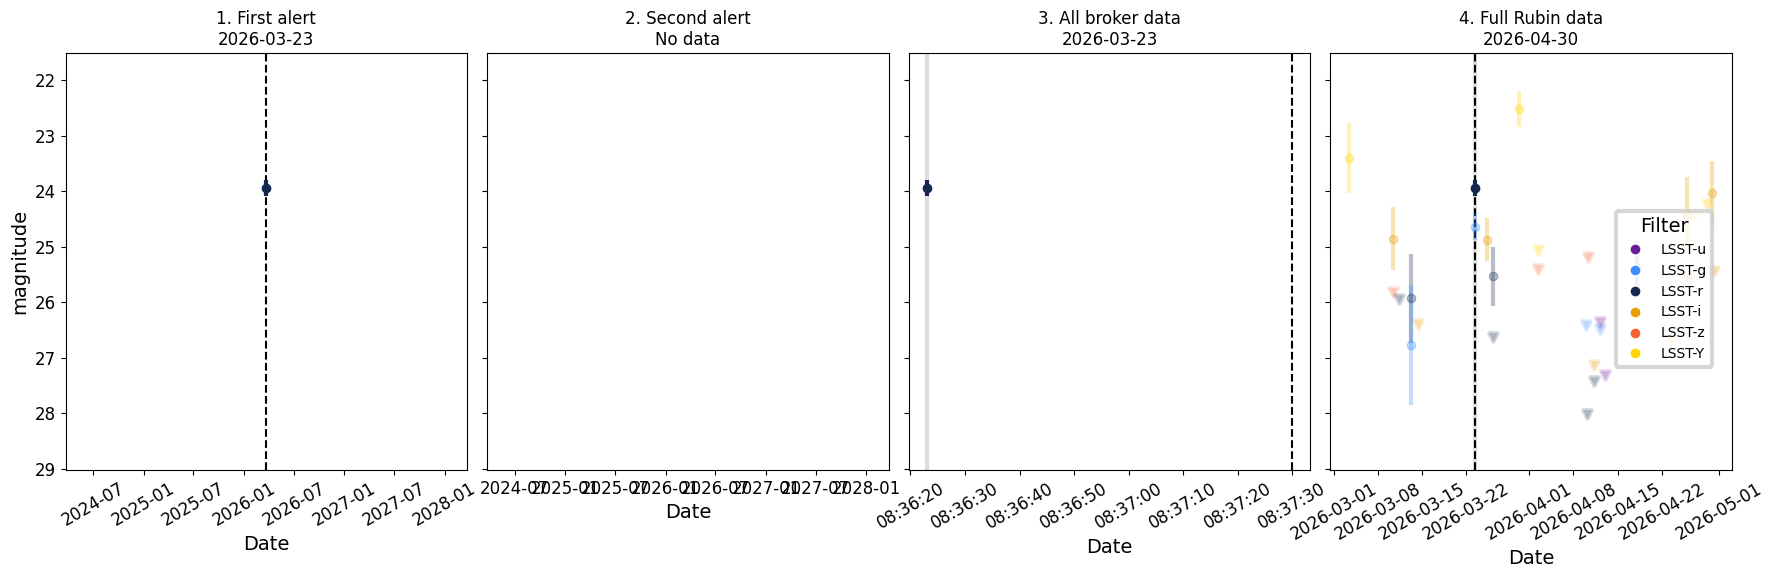

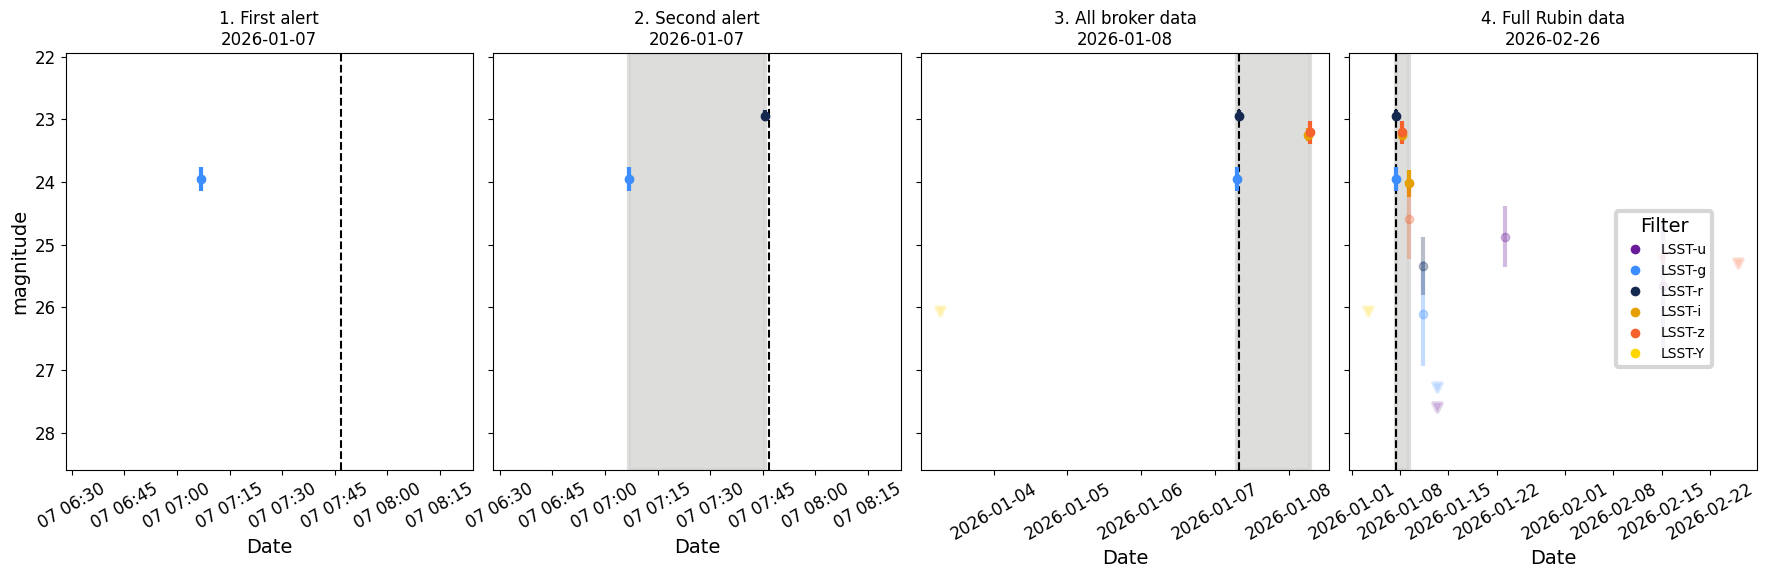

In [12]:
for idx in list(set(snids_all_snr_gt5))[:5]:
    # plot_lc_subplots(df_phot,df_header, idx, inmag=True,convert_date=True)
    au.plot_lc_subplots_matplotlib(df_phot, df_header, idx, inmag=True, convert_date=True)


# Best sampling

In [13]:
top_10_snids_by_magnitude_count = (
    df_phot[(df_phot['magnitude'].notnull()) & (df_phot['SNR']>5)]
    .groupby('SNID')
    .size()
    .sort_values(ascending=False)
    .head(15)
)


SNID 3823_Kasen z=0.08
SNID 20410_Bulla z=0.07
SNID 5084_Bulla z=0.06
SNID 3412_Kasen z=0.05
SNID 6062_Kasen z=0.01
SNID 5484_Bulla z=0.04
SNID 18739_Kasen z=0.10
SNID 8765_Kasen z=0.07
SNID 16415_Kasen z=0.07
SNID 4344_Bulla z=0.04
SNID 19955_Bulla z=0.02
SNID 22303_Bulla z=0.11
SNID 11444_Bulla z=0.04
SNID 9932_Kasen z=0.08
SNID 23207_Kasen z=0.01


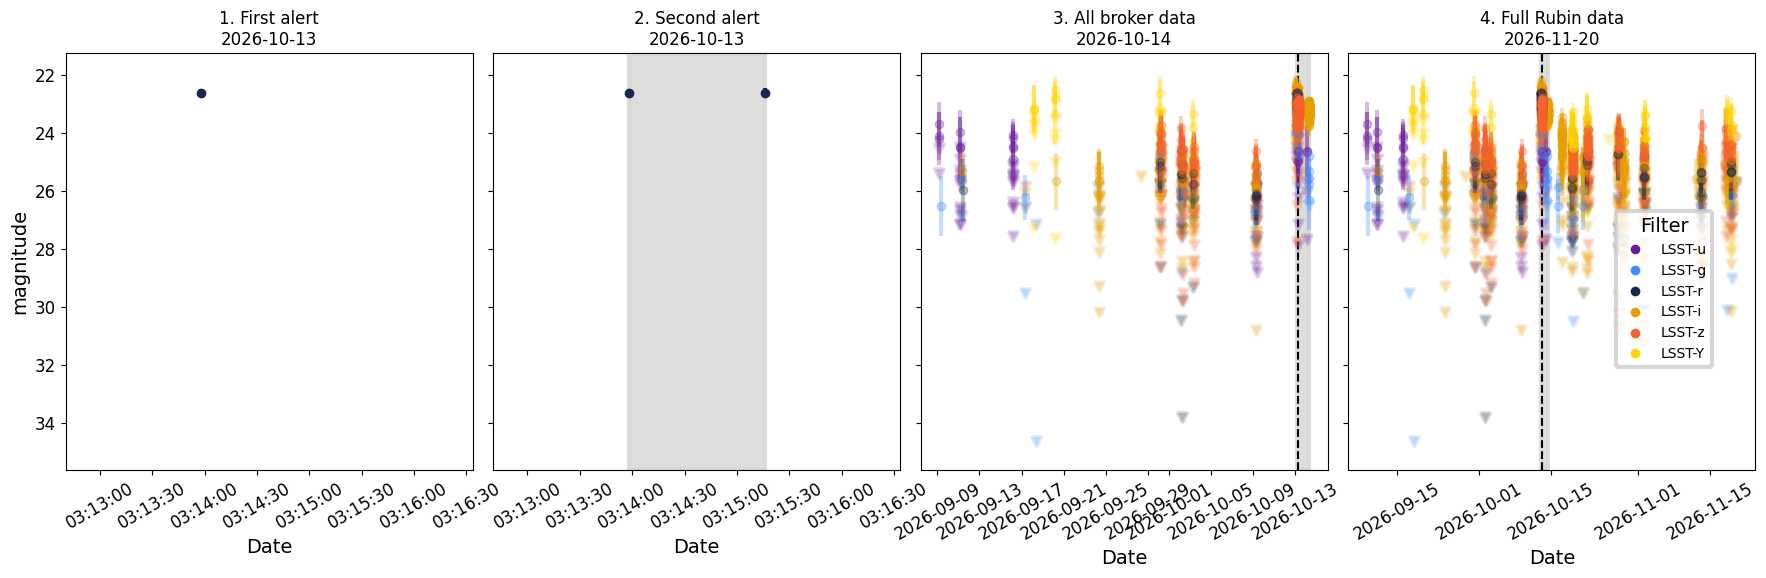

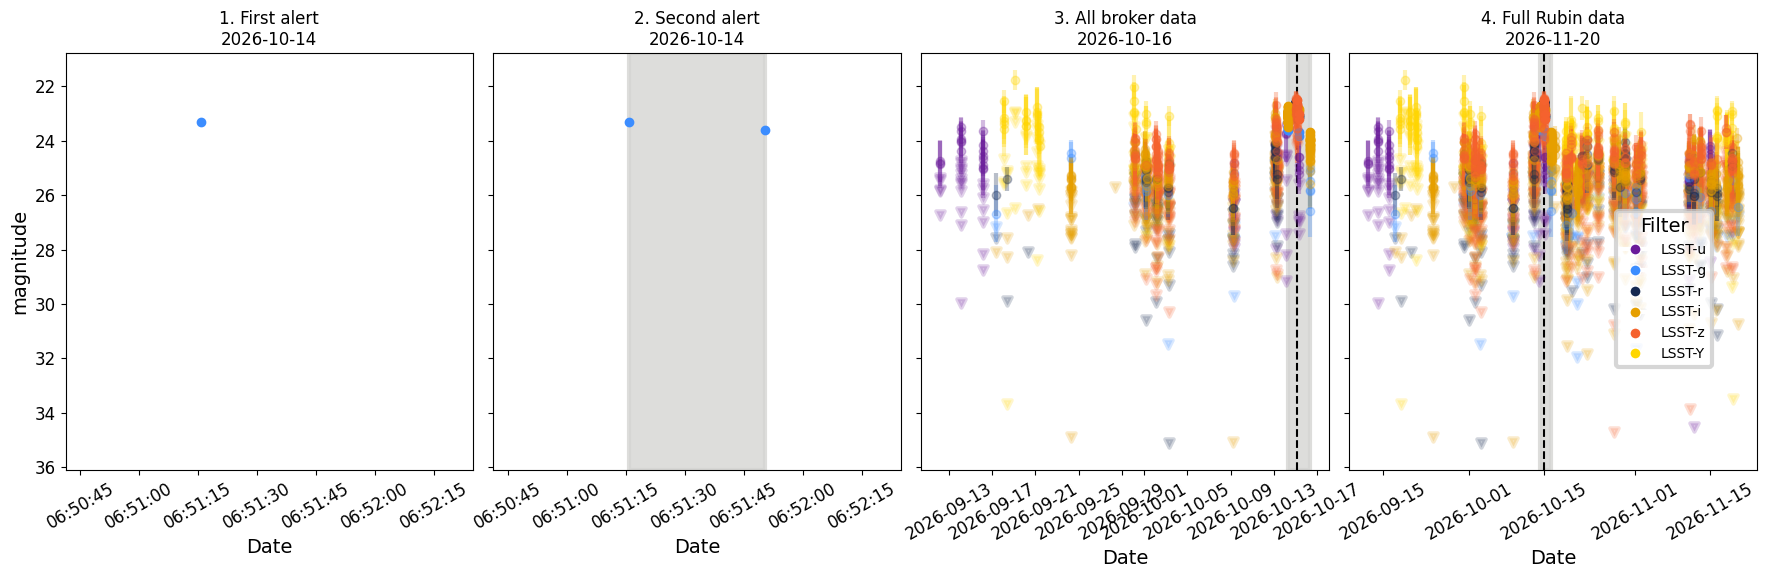

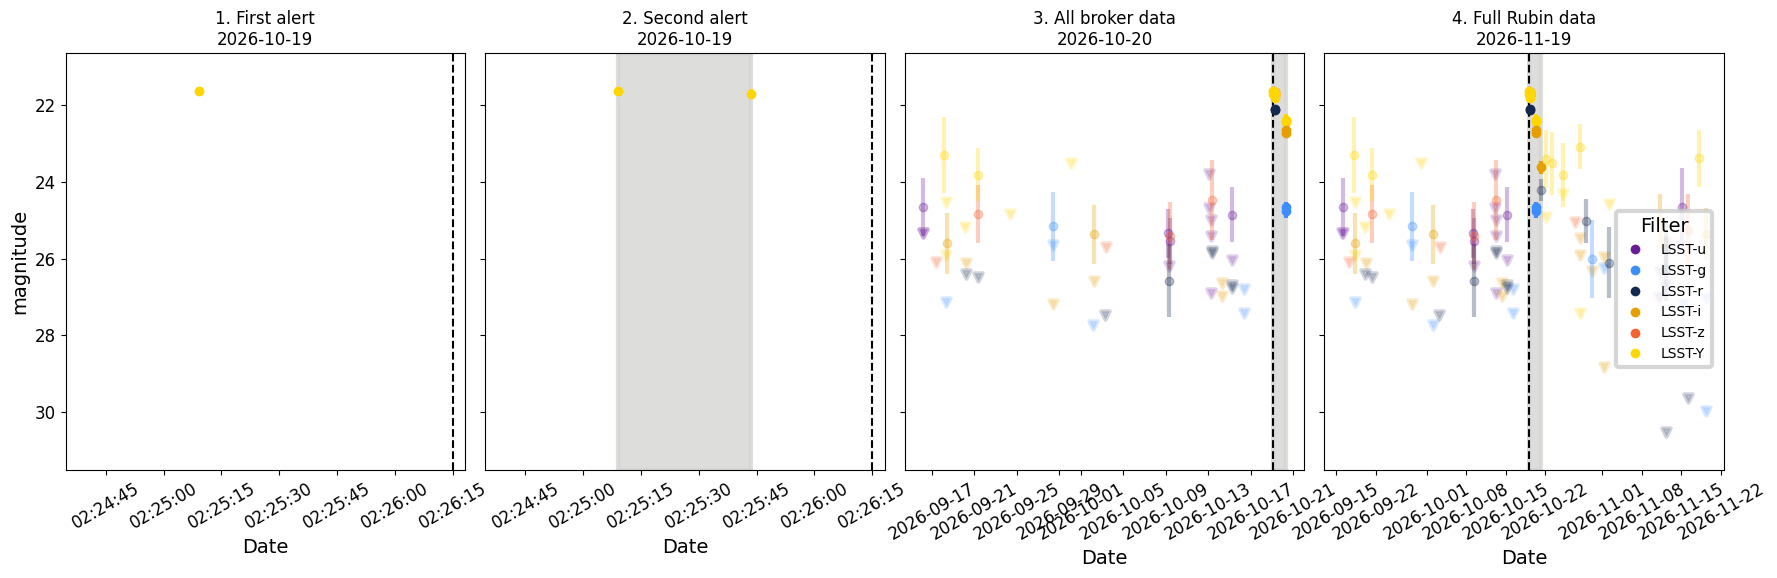

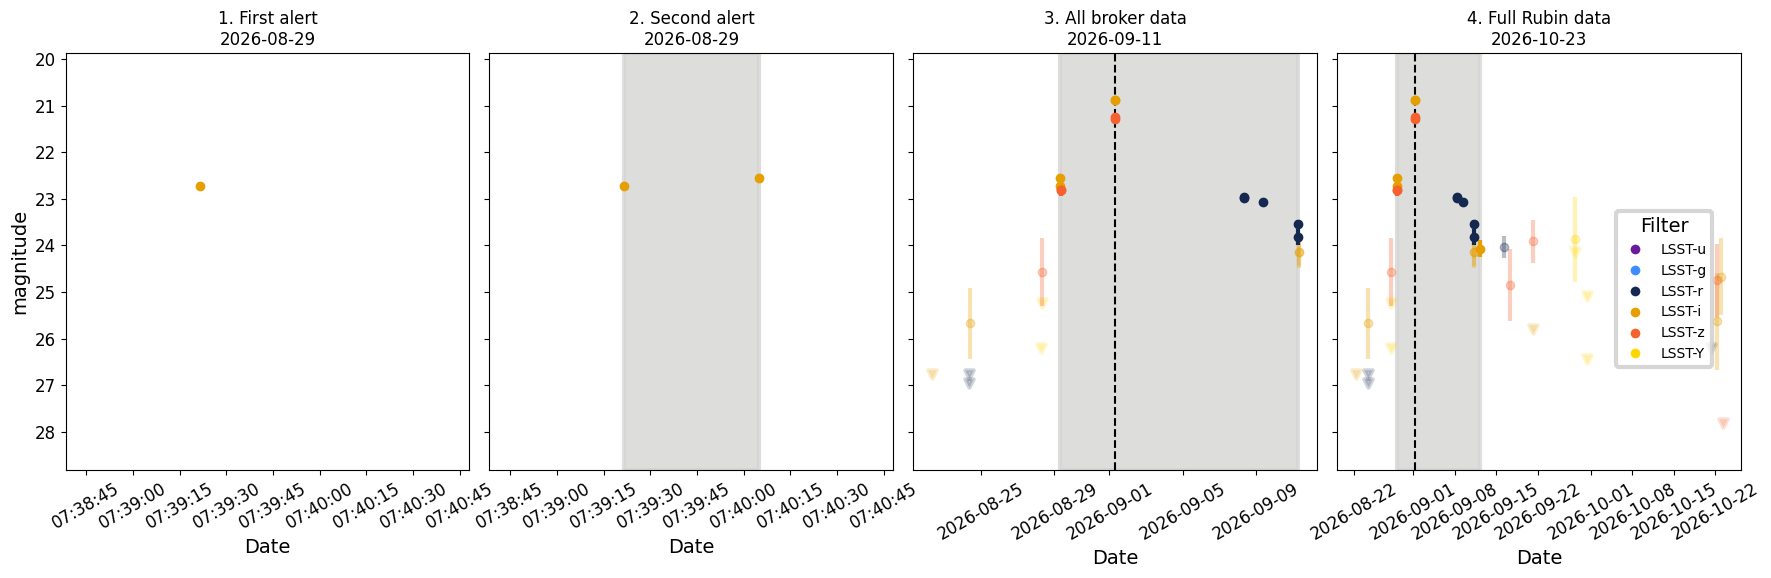

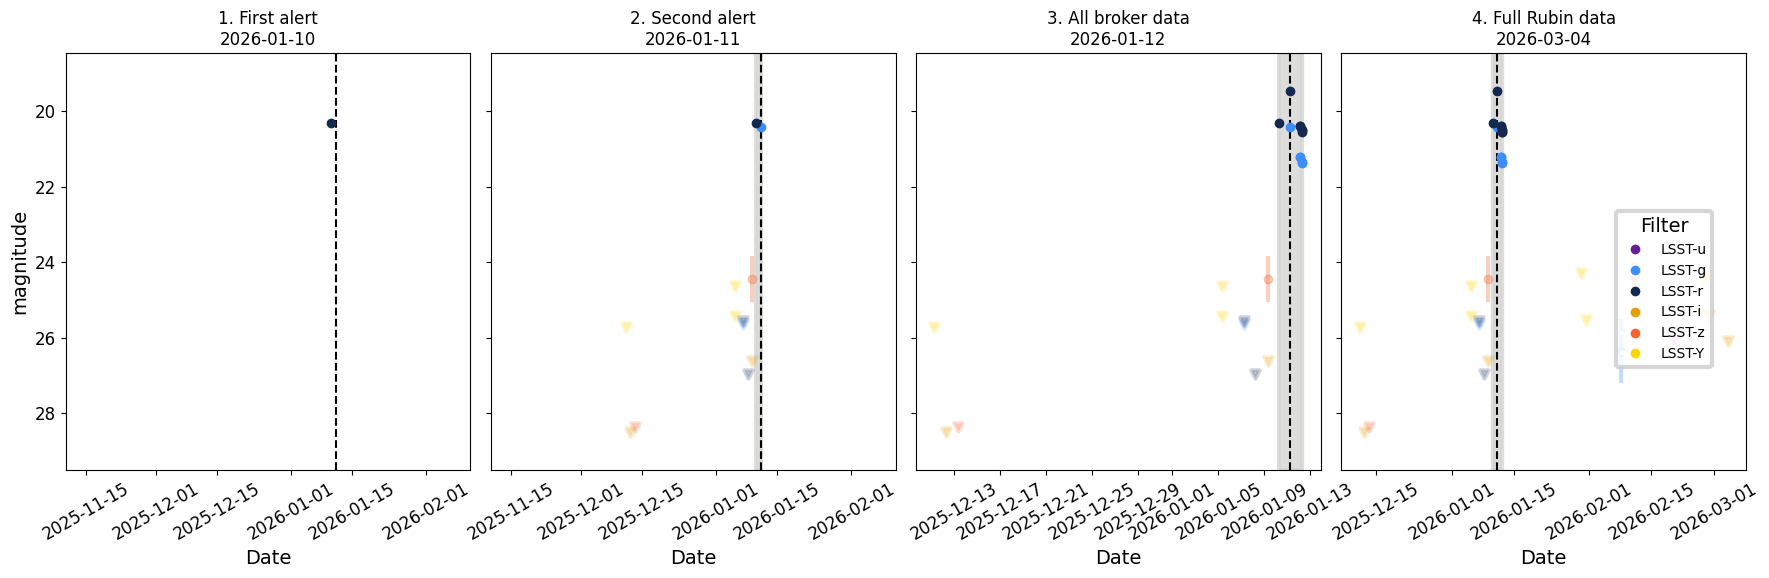

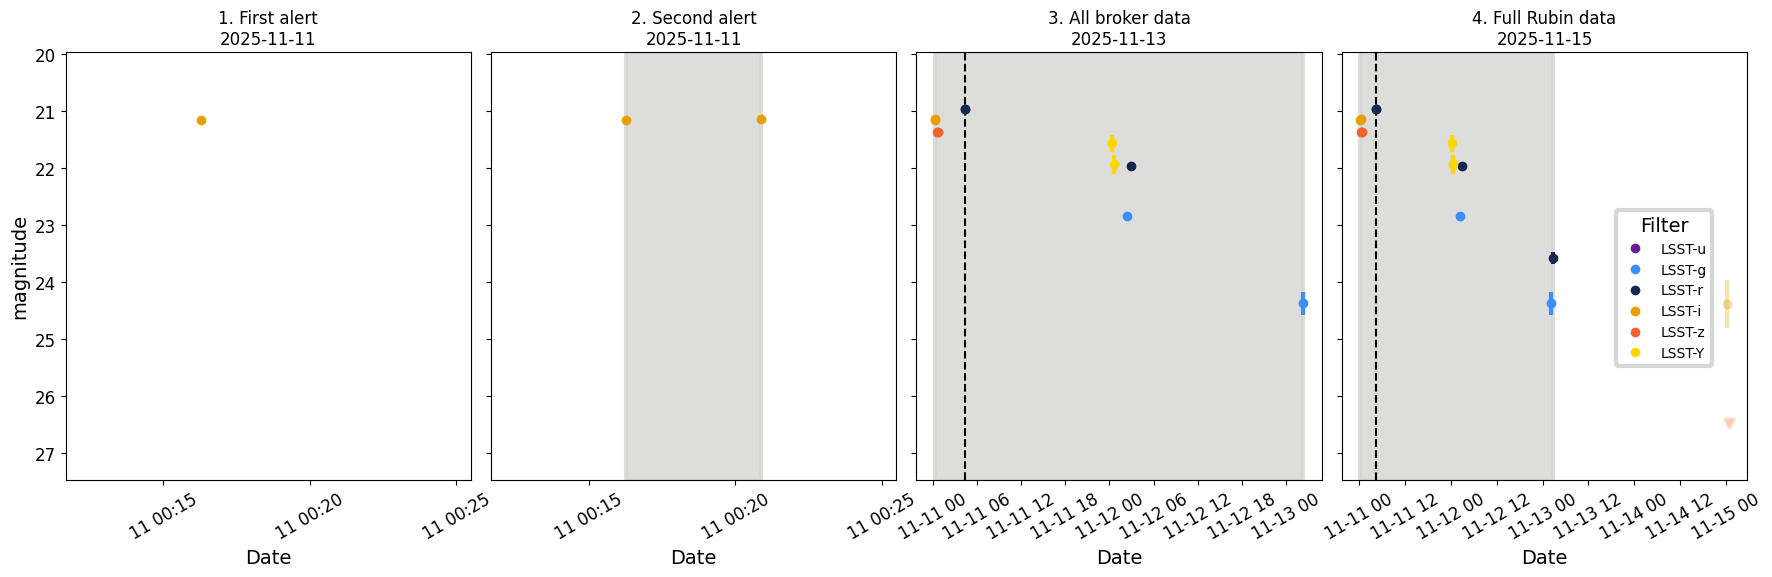

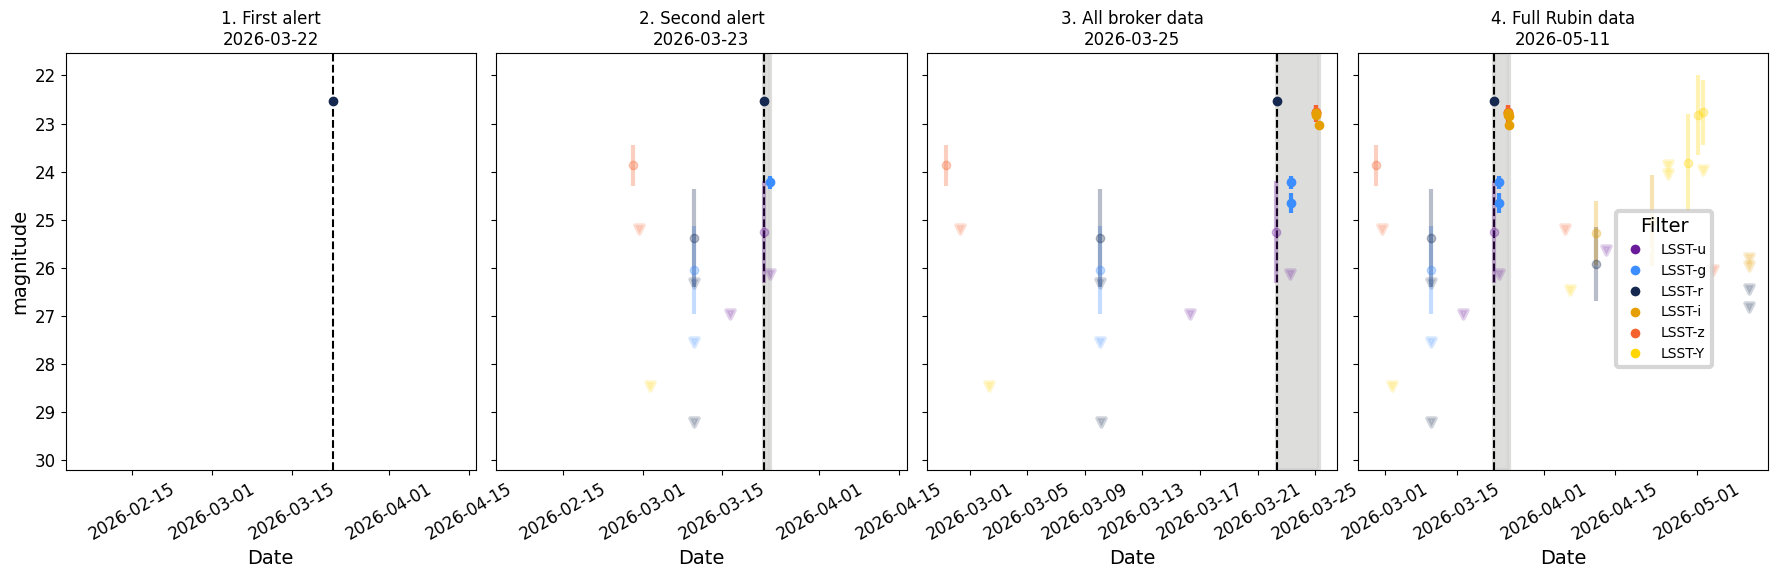

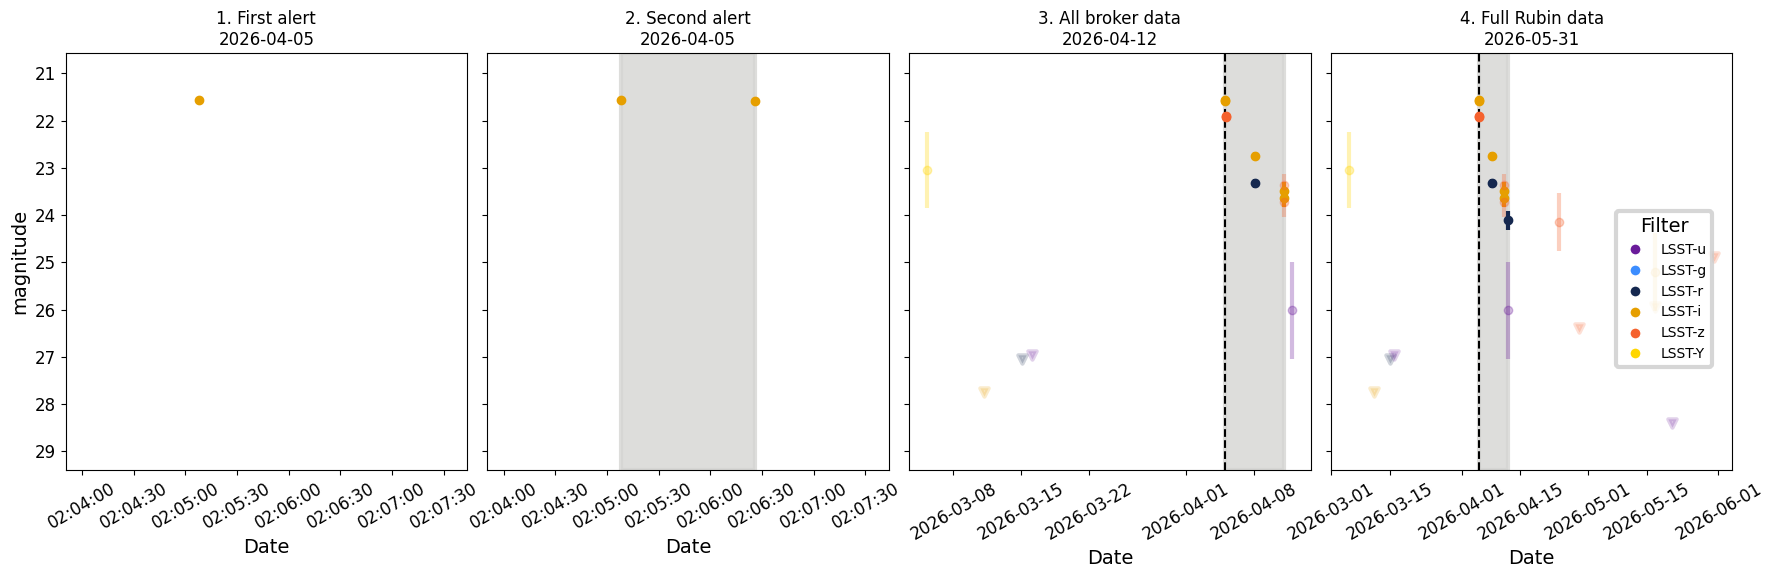

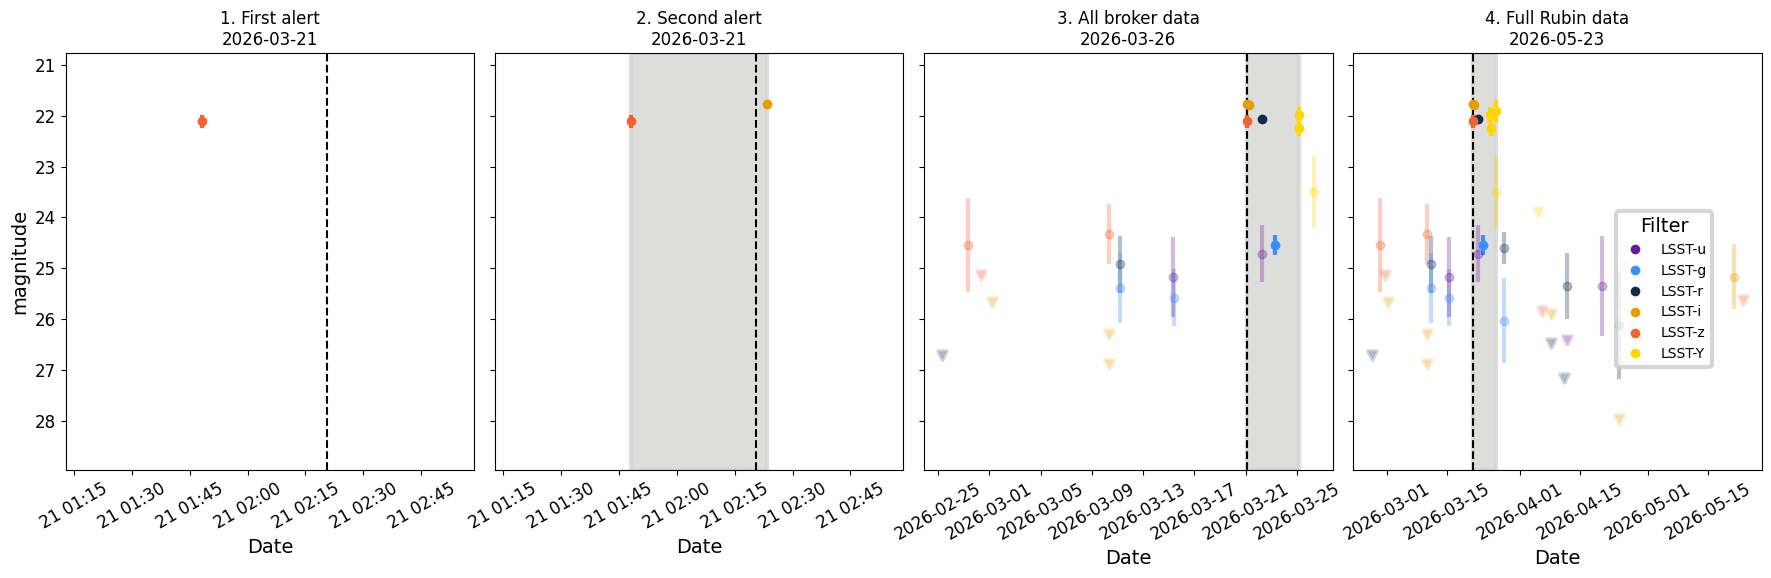

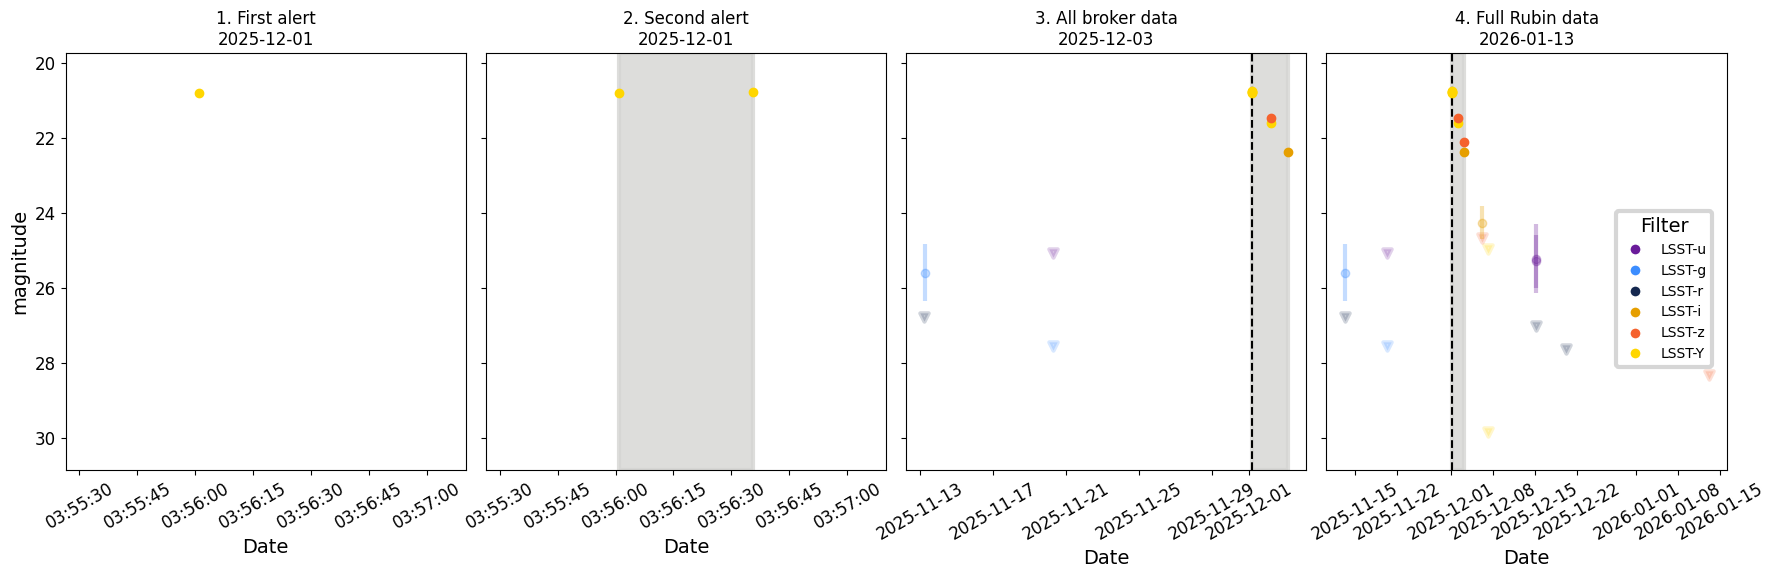

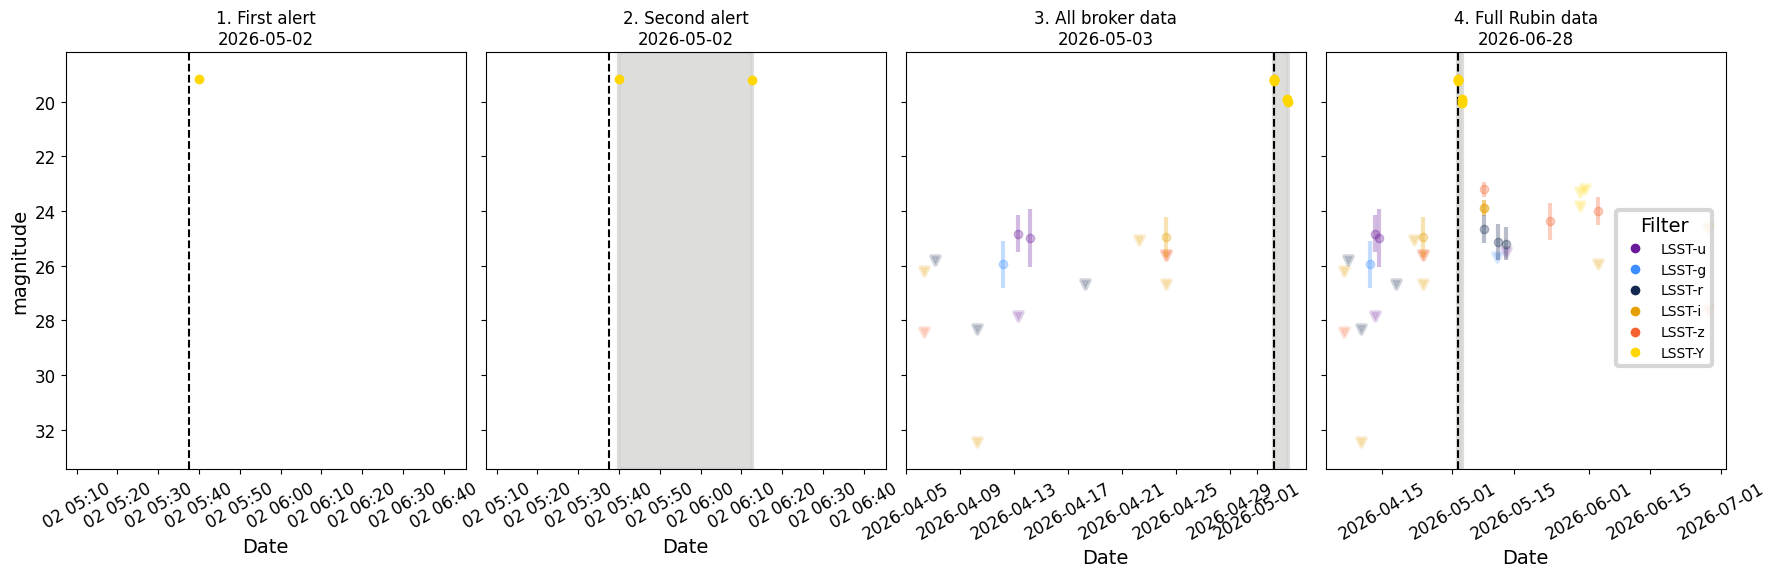

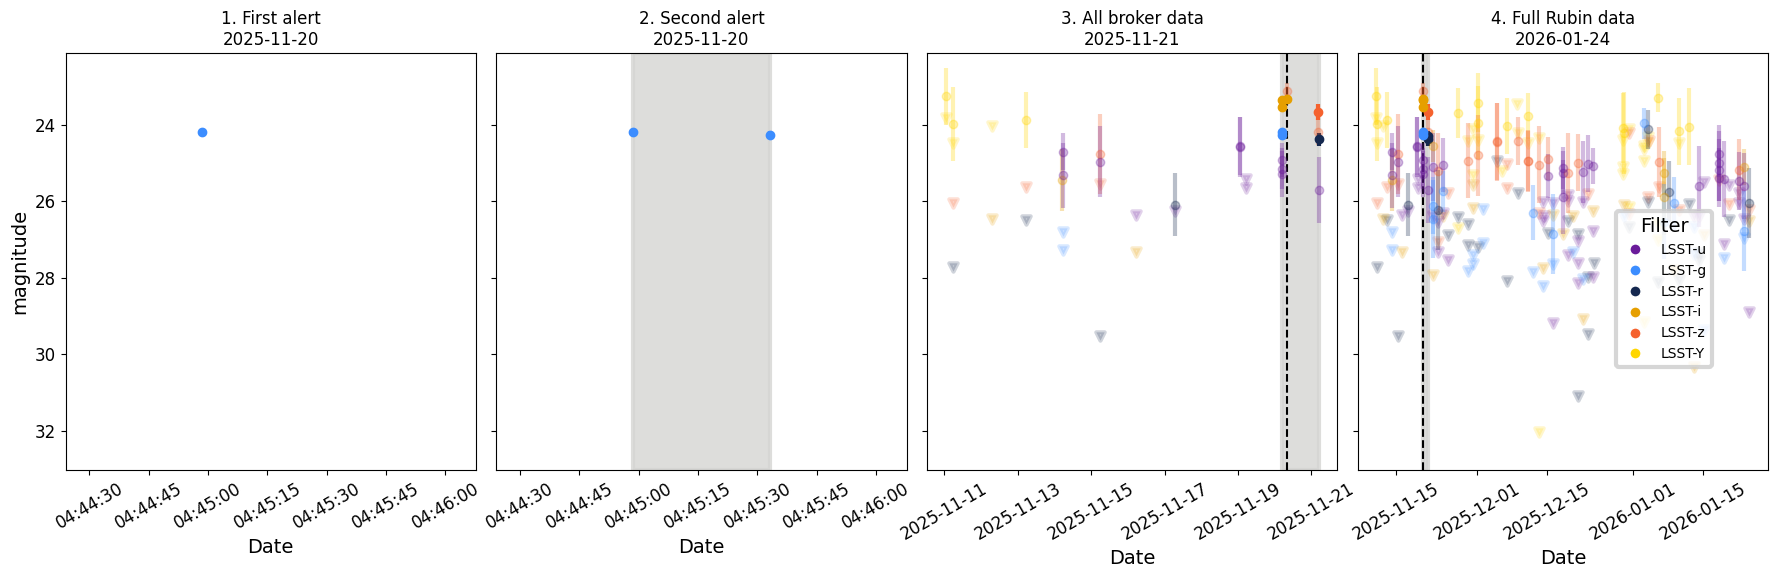

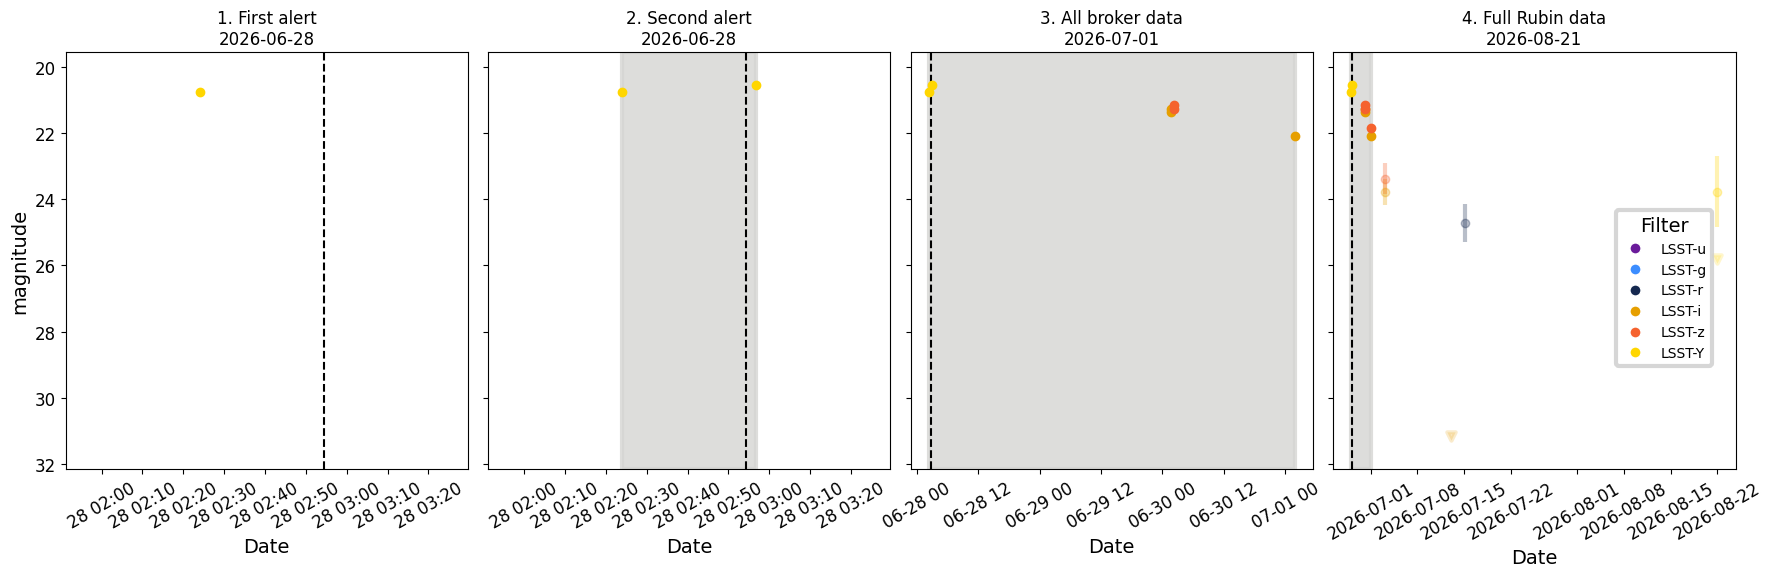

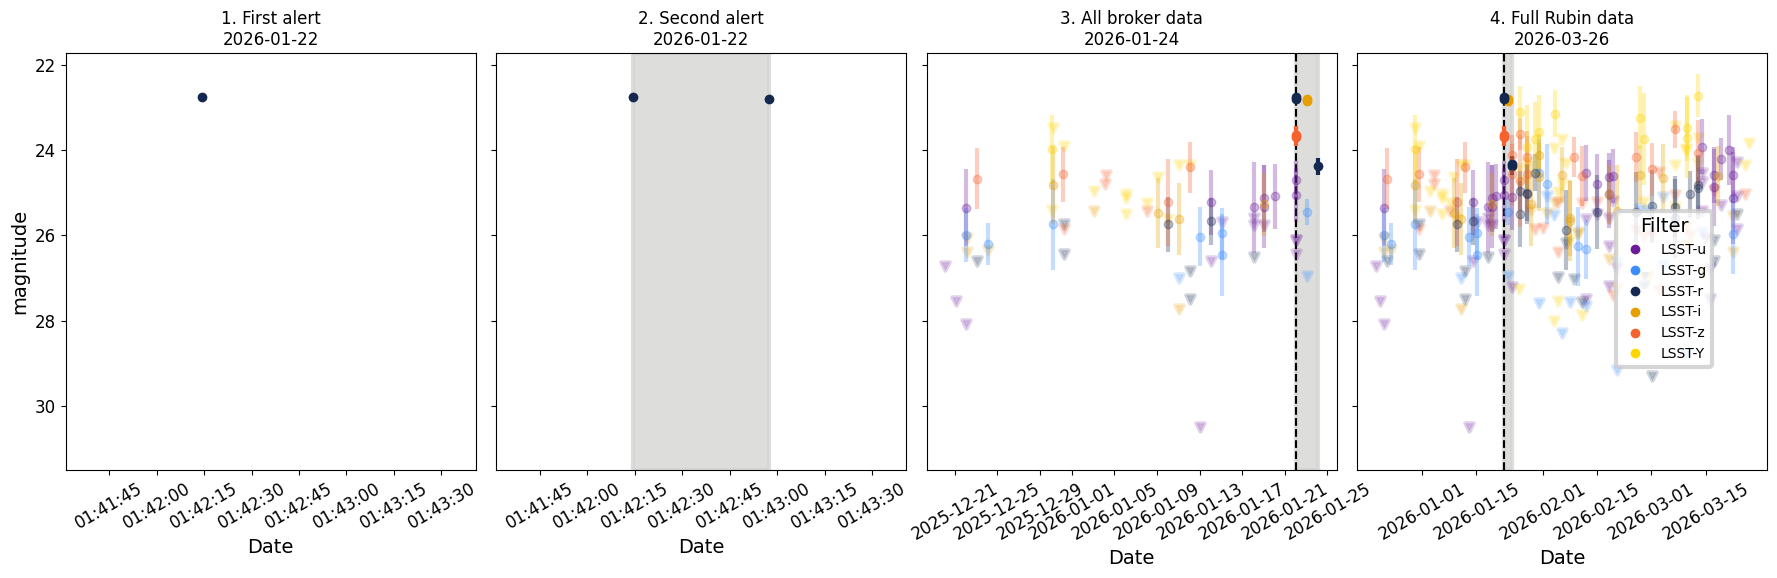

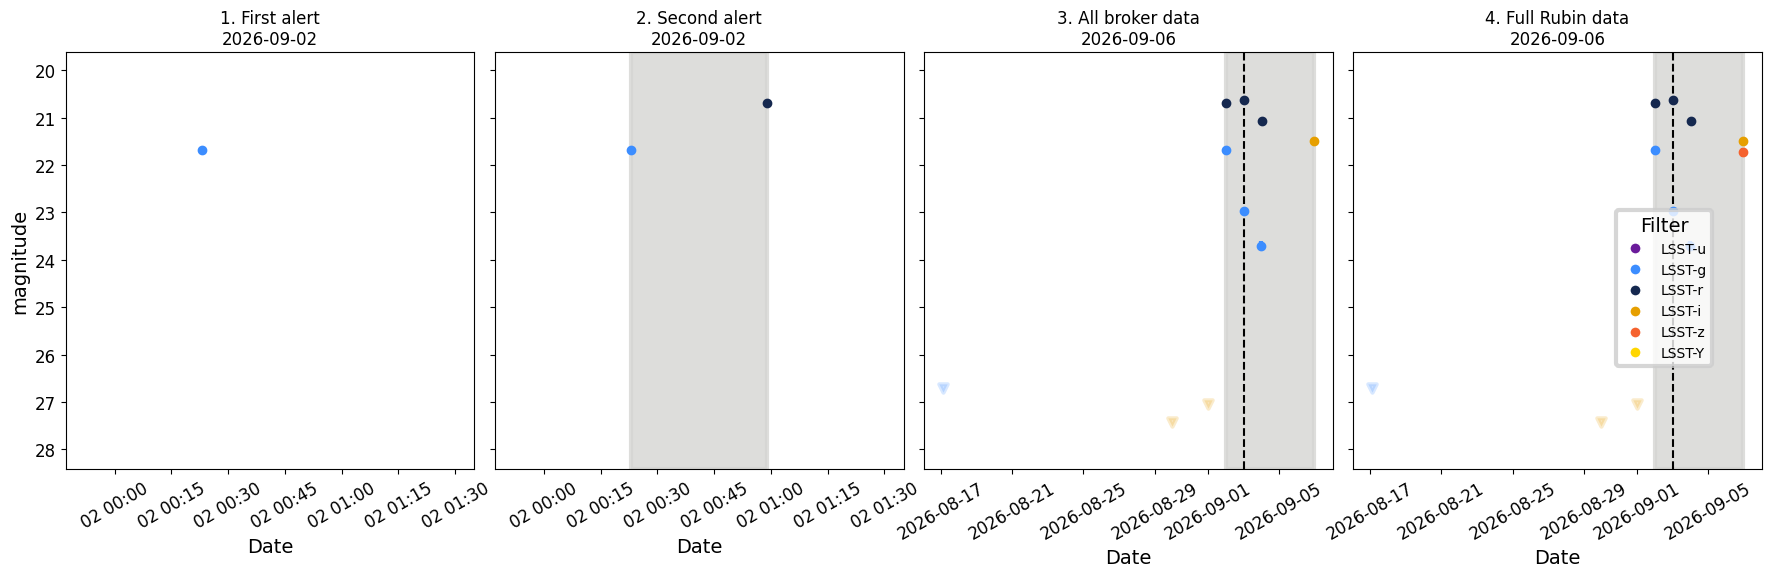

In [14]:
for idx in top_10_snids_by_magnitude_count.index:
    # plot_lc_subplots(df_phot,df_header, idx, inmag=True,convert_date=True)
    au.plot_lc_subplots_matplotlib(df_phot, df_header, idx, inmag=True, convert_date=True, savefig=True, path_plots=path_plots)

# DDF + at least one detection in broker

# How early are we detecting them?

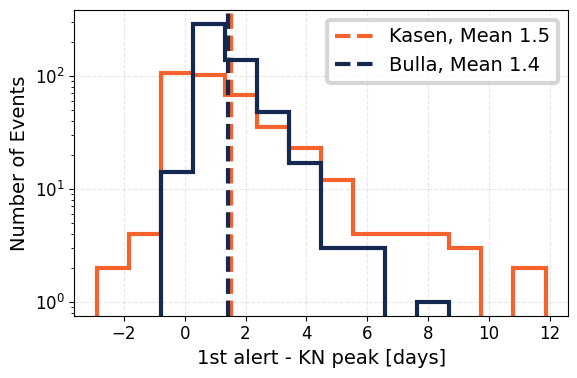

In [15]:
# Filter to SNR > 5 detections
snr5 = df_phot[df_phot['SNR'] > 5].copy()

# Get first MJD with SNR > 5 per SNID
first_snr5 = snr5.groupby('SNID')['MJD'].min().rename('first_snr5_mjd')

# Merge with header to align with PEAKMJD
df_header_w1stsnr5 = df_header.merge(first_snr5, on='SNID', how='left')

# Compute signed difference: PEAK - first SNR > 5
df_header_w1stsnr5['delta_snr5_peak'] = np.where(
    df_header_w1stsnr5['SIM_PEAKMJD'] > 0,
    df_header_w1stsnr5['first_snr5_mjd'] - df_header_w1stsnr5['SIM_PEAKMJD'],
    np.nan
)

# Histogram bins
bins = np.linspace(df_header_w1stsnr5['delta_snr5_peak'].min(), df_header_w1stsnr5['delta_snr5_peak'].max(), 15) 

plt.figure(figsize=(6, 4))

for typ in df_header_w1stsnr5.SIM_GENTYPE.unique():
    # Filter headers for current SN type
    sel_header = df_header_w1stsnr5[(df_header_w1stsnr5.SIM_GENTYPE == typ)].copy()
    
    # Drop NaNs
    data_snr5 = sel_header['delta_snr5_peak'].dropna()
    
    # Choose color per type
    color = au.dic_KN_models_colors[au.dic_sntype[str(typ)]]
    
    # Step histogram
    plt.hist(data_snr5, bins=bins, histtype='step', color=color)
    
    # Mean line
    mean_snr5 = data_snr5.mean()
    plt.axvline(mean_snr5, color=color, linestyle='dashed',
                label=f'{au.dic_sntype[str(typ)]}, Mean {mean_snr5:.1f}')
    
plt.xlabel('1st alert - KN peak [days]')
plt.ylabel('Number of Events')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f'{path_plots}/first_alert_vs_peak.png')

Kasen 0.013249999999970896 2.3396111439730984
Kasen 1.0033000000039465 0.8477209623432188
Bulla 0.011700000002747402 0.8966465898986002
Bulla 1.0337999999974272 0.8613253845078186


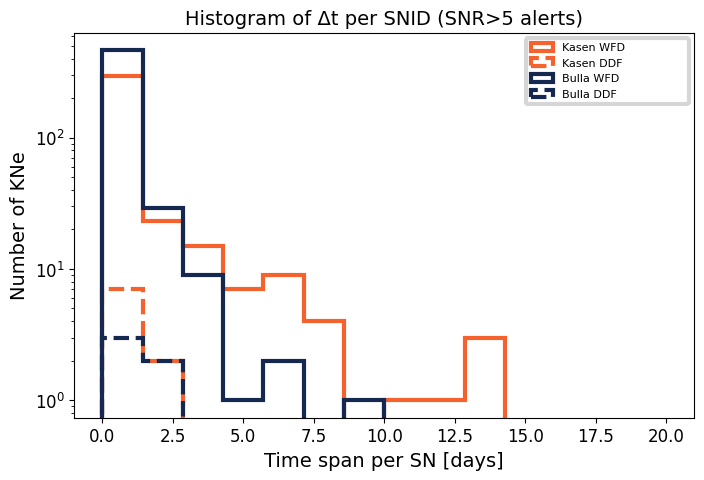

In [16]:
plt.figure(figsize=(8,5))
mybins = np.linspace(0, 20, 15)  # Adjust bins as needed

for mod in snr5['model_name'].unique():
    for f in snr5['FIELD'].unique():
        sel = snr5[(snr5['model_name'] == mod) & (snr5['FIELD'] == f)]
        if len(sel) == 0:
            continue
        
        # compute delta_times for this group only
        delta_times_group = sel.groupby("SNID")["MJD"].agg(lambda x: x.max() - x.min())
        
        # handle bytes or str
        f_str = f.decode() if isinstance(f, bytes) else f
        linestyle = '-' if 'WFD' in f_str else '--'
        plt.hist(delta_times_group, bins=mybins, histtype='step', color=au.dic_KN_models_colors.get(mod, 'k') , linestyle=linestyle, label=f"{mod} {f_str}")
        median_val = delta_times_group.median()
        print(mod,median_val,std_val := delta_times_group.std())

plt.xlabel("Time span per SN [days]")
plt.ylabel("Number of KNe")
plt.yscale("log")
plt.title("Histogram of Δt per SNID (SNR>5 alerts)")
plt.legend(fontsize=8)
plt.show()


In [17]:
# mydelta = snr5.groupby("SNID")["MJD"].agg(lambda x: x.max() - x.min())
# idxs = mydelta[mydelta>10].index
# for idx in idxs:
#     plot_lc_subplots_matplotlib(df_phot, df_header, idx, inmag=True, convert_date=True)


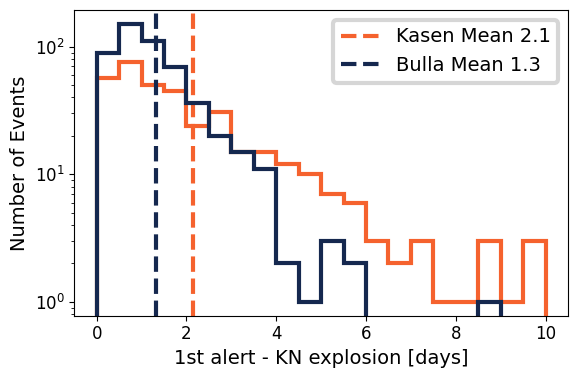

In [18]:
   
plt.figure(figsize=(6, 4))
bins = np.linspace(0, 10, 21)  # 10 bins between 0 and 10

for typ in df_header.SIM_GENTYPE.unique():
    sel_header = df_header_w1stsnr5[df_header_w1stsnr5.SIM_GENTYPE == typ].copy()
    sel = df_phot[df_phot.SNID.isin(sel_header.SNID)]
    
    # Compute delta between peak and explosion
    sel_header['delta_firstalert_explode'] = sel_header['first_snr5_mjd'] - sel_header['SIM_MJD_EXPLODE']

    # Choose color per type
    color = au.dic_KN_models_colors[au.dic_sntype[str(typ)]]
    
    # All events (dashed step)
    # plt.hist(data_all, bins=bins, histtype='step', linestyle='dashed', color=color,linewidth=1.5)
    
    # SNR>5 events (solid step)
    plt.hist(sel_header['delta_firstalert_explode'], bins=bins, histtype='step', color=color)

    mean_snr = sel_header['delta_firstalert_explode'].mean()
    plt.axvline(mean_snr, color=color, linestyle='dashed', 
                label=f'{au.dic_sntype[str(typ)]} Mean {mean_snr:.1f}')

plt.xlabel('1st alert - KN explosion [days]')
plt.ylabel('Number of Events')
plt.legend()
plt.yscale('log')
plt.tight_layout()
plt.savefig(f'{path_plots}/first_alert_vs_explosion.png')
plt.show()


# How bright?

In [19]:
idx_max_flux = df_phot.groupby(['SNID', 'BAND'])['FLUXCAL'].idxmax()
df_max_flux = df_phot.loc[idx_max_flux].reset_index(drop=True)
# df_max_flux

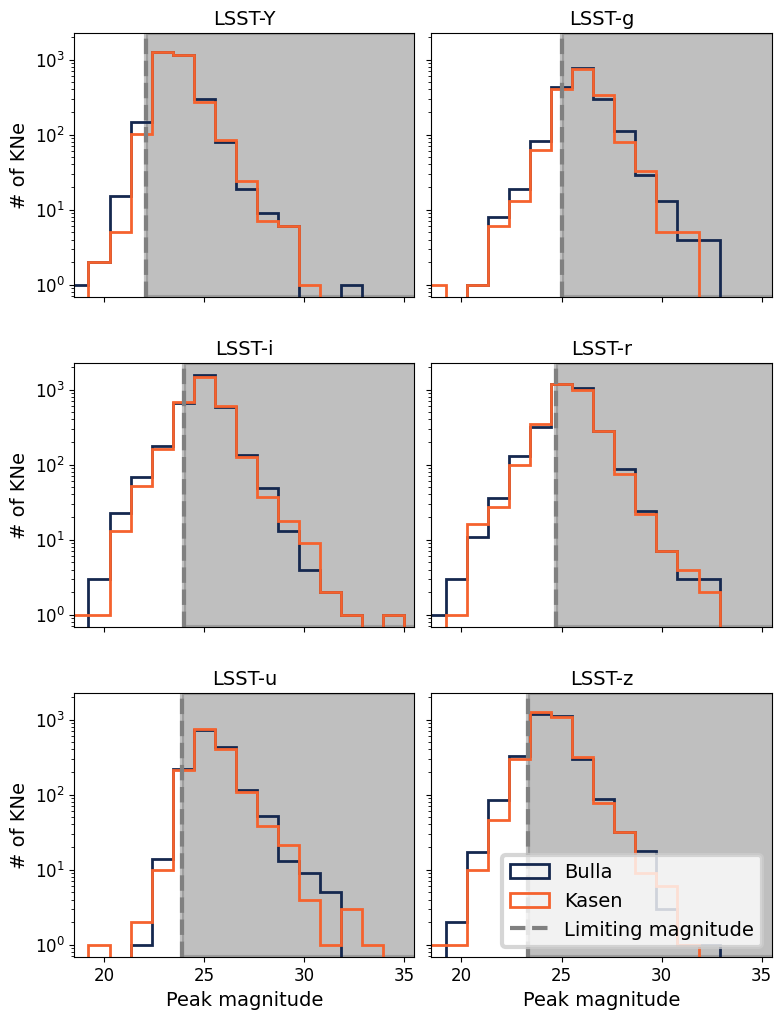

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(9, 12), sharey=True, sharex=True)
plt.subplots_adjust(wspace=0.05, hspace=0.25)

mybins = np.linspace(15, 35, 20)  # Bins for histogram

axes = axes.flatten()  # flatten 3x2 grid into 1D array for easy looping
bands = sorted(df_phot['BAND'].unique())  # sorted to control order

for ax, flt in zip(axes, bands):
    ax.set_title(flt)
    for mod in ['Bulla', 'Kasen']:
        sel_max_flux = df_max_flux[
            (df_max_flux['model_name'] == mod) &
            (df_max_flux['BAND'] == flt)
        ]
        ax.hist(
            sel_max_flux['magnitude'],
            bins=mybins,
            label=mod,
            color=au.dic_KN_models_colors[mod],
            histtype='step',
            linewidth=2,
        )

    # vertical line + shaded region
    ax.axvline(x=au.dic_limiting_mags[flt], color='grey', linestyle='--', label='Limiting magnitude')
    ax.axvspan(au.dic_limiting_mags[flt], ax.get_xlim()[1], color='grey', alpha=0.5)

axes[4].set_xlabel("Peak magnitude")
axes[5].set_xlabel("Peak magnitude")

# shared y-label
axes[0].set_ylabel("# of KNe")
axes[2].set_ylabel("# of KNe")  # also label the 2nd row
axes[4].set_ylabel("# of KNe")  # also label the 3rd row

plt.yscale("log")
plt.xlim(18.5, 35.5)
plt.legend(loc='lower right')
plt.savefig(f'{path_plots}/hist_mags.png')
plt.show()

## Follow-up

### How many could be also detected by ZTF?

In [21]:
lim_mag = 21.5
for mod in ['Bulla', 'Kasen']:
    sel_max_flux = df_max_flux[
        (df_max_flux['model_name'] == mod) &
        (df_max_flux['magnitude'] < lim_mag)
    ]
    unique_snids = sel_max_flux['SNID'].nunique()
    total_snids = df_header[df_header['model_name'] == mod]['SNID'].nunique()
    print(f"{mod}: {unique_snids} KNe with peak magnitude < {lim_mag} ({unique_snids / total_snids * 100:.2f}% of total {total_snids})")

Bulla: 69 KNe with peak magnitude < 21.5 (1.62% of total 4261)
Kasen: 47 KNe with peak magnitude < 21.5 (1.11% of total 4226)


### How many are bright enought o be followed-up by ANU 2.3m?

In [22]:
lim_mag = 19.5
for mod in ['Bulla', 'Kasen']:
    sel_max_flux = df_max_flux[
        (df_max_flux['model_name'] == mod) &
        (df_max_flux['magnitude'] < lim_mag)
    ]
    unique_snids = sel_max_flux['SNID'].nunique()
    total_snids = df_header[df_header['model_name'] == mod]['SNID'].nunique()
    print(f"{mod}: {unique_snids} KNe with peak magnitude < {lim_mag} ({unique_snids / total_snids * 100:.2f}% of total {total_snids})")

Bulla: 2 KNe with peak magnitude < 19.5 (0.05% of total 4261)
Kasen: 2 KNe with peak magnitude < 19.5 (0.05% of total 4226)


### How many are faint that need 8-class meter telescope?

In [23]:
lim_mag = 22 # TiDES limit
for mod in ['Bulla', 'Kasen']:
    sel_max_flux = df_max_flux[
        (df_max_flux['model_name'] == mod) &
        (df_max_flux['magnitude'] > lim_mag)
    ]
    unique_snids = sel_max_flux['SNID'].nunique()
    total_snids = df_header[df_header['model_name'] == mod]['SNID'].nunique()
    print(f"{mod}: {unique_snids} KNe with peak magnitude > {lim_mag} ({unique_snids / total_snids * 100:.2f}% of total {total_snids})")

Bulla: 4102 KNe with peak magnitude > 22 (96.27% of total 4261)
Kasen: 4050 KNe with peak magnitude > 22 (95.84% of total 4226)


In [24]:
lim_mag = 24 
bright_mag = 22 # TiDES limit
for mod in ['Bulla', 'Kasen']:
    sel_max_flux = df_max_flux[
        (df_max_flux['model_name'] == mod) &
        (df_max_flux['magnitude'] > bright_mag) & (df_max_flux['magnitude'] < lim_mag)
    ]
    unique_snids = sel_max_flux['SNID'].nunique()
    total_snids = df_header[df_header['model_name'] == mod]['SNID'].nunique()
    print(f"{mod}: {unique_snids} KNe with {lim_mag} < peak magnitude < {bright_mag} ({unique_snids / total_snids * 100:.2f}% of total {total_snids})")

Bulla: 2704 KNe with 24 < peak magnitude < 22 (63.46% of total 4261)
Kasen: 2708 KNe with 24 < peak magnitude < 22 (64.08% of total 4226)


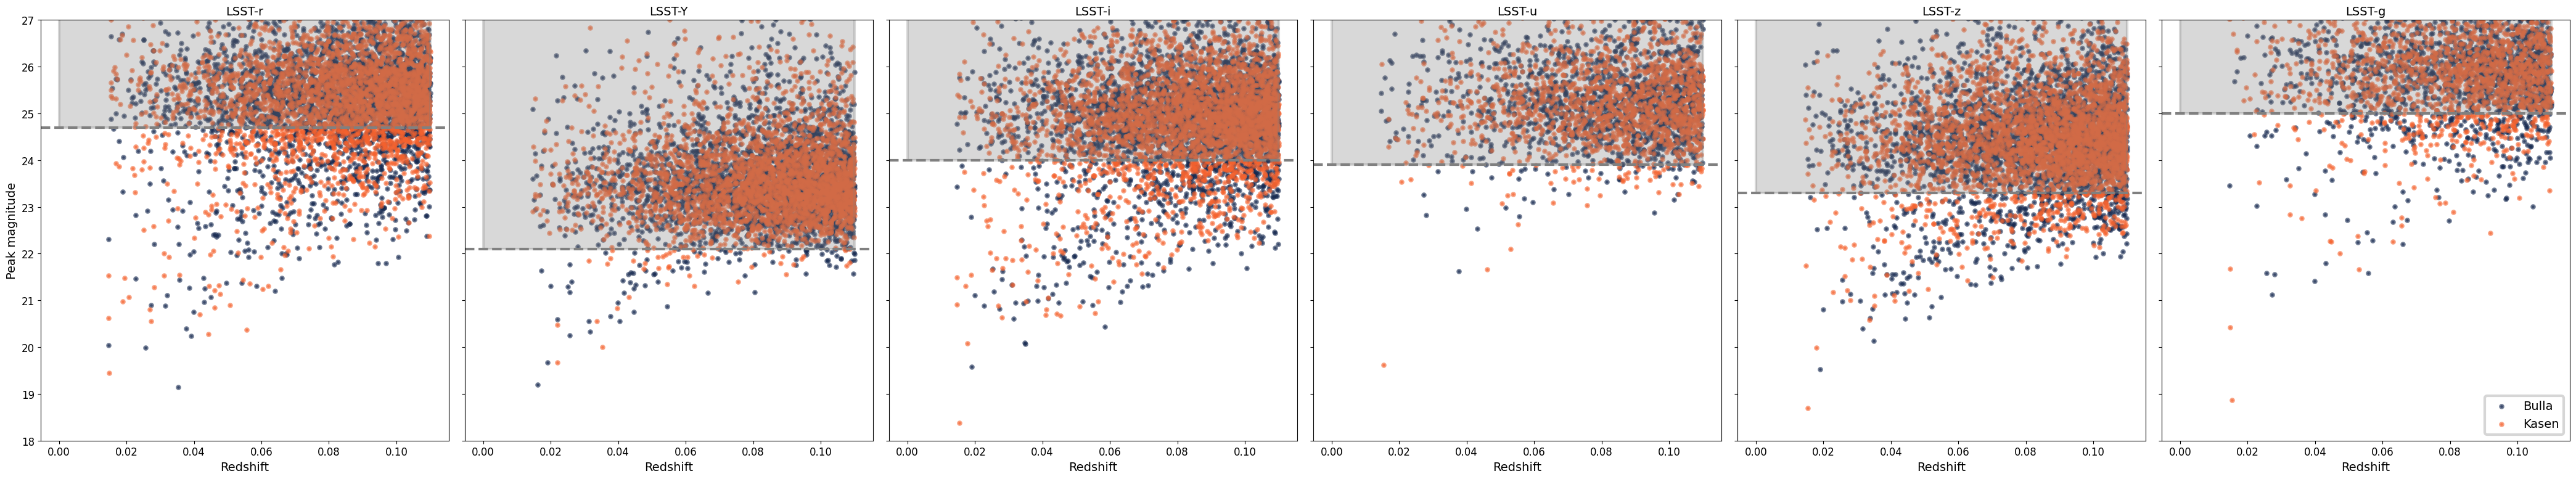

In [25]:
# Merge redshift into the max flux dataframe
df_with_z = df_max_flux.merge(
    df_header[['SNID', 'SIM_REDSHIFT_CMB']], 
    on='SNID', how='left'
)
bands = df_with_z['BAND'].unique()
fig, axes = plt.subplots(1, len(bands), figsize=(7*len(bands), 8), sharey=True, sharex=False)

for ax, flt in zip(axes, bands):
    ax.set_title(flt)
    for mod in ['Bulla', 'Kasen']:
        sel = df_with_z[
            (df_with_z['model_name'] == mod) &
            (df_with_z['BAND'] == flt)
        ]
        ax.scatter(
            sel['SIM_REDSHIFT_CMB'], sel['magnitude'],
            s=10, alpha=0.6,
            label=mod,
            color=au.dic_KN_models_colors[mod]
        )

    # limiting magnitude line (horizontal this time)
    ax.axhline(y=au.dic_limiting_mags[flt], color='grey', linestyle='--')
    ax.fill_between(
        [0, df_header['SIM_REDSHIFT_CMB'].max()],  # x-range
        au.dic_limiting_mags[flt],  # lower bound
        df_phot['magnitude'].max(),        # upper bound
        color='grey', alpha=0.3
    )
    ax.set_xlabel("Redshift")
    
axes[0].set_ylabel("Peak magnitude")
plt.ylim(18, 27)
plt.legend()
plt.tight_layout()
plt.show()


### is there a more predominant color we can use?

In [26]:
pairs = []
for snid, group in df_max_flux.groupby("SNID"):
    group = group.sort_values("MJD")

    for i, row1 in group.iterrows():
        for j, row2 in group.iterrows():
            if row1.BAND == row2.BAND:
                continue
            dt = abs(row1.MJD - row2.MJD)
            if dt <= 0.7:
                # enforce a consistent band ordering
                band1, band2 = sorted([row1.BAND, row2.BAND])
                if band1 == row1.BAND:
                    mag1, mag2 = row1.magnitude, row2.magnitude
                    snr1, snr2 = row1.SNR, row2.SNR
                else:
                    mag1, mag2 = row2.magnitude, row1.magnitude
                    snr1, snr2 = row2.SNR, row1.SNR

                mag_diff = mag1 - mag2
                colour = f"{band1}-{band2}"

                pairs.append({
                    "SNID": snid,
                    "BAND1": band1,
                    "BAND2": band2,
                    "MJD1": row1.MJD,
                    "MJD2": row2.MJD,
                    "MAG1": mag1,
                    "MAG2": mag2,
                    "dt": dt,
                    "colour": colour,
                    "mag_diff": mag_diff,
                    "SNR1": snr1,
                    "SNR2": snr2,
                    "model":row1.SNID.split("_")[1]
                })

df_colours = pd.DataFrame(pairs).drop_duplicates(
    subset=["SNID", "BAND1", "BAND2", "MJD1", "MJD2"]
).reset_index(drop=True)


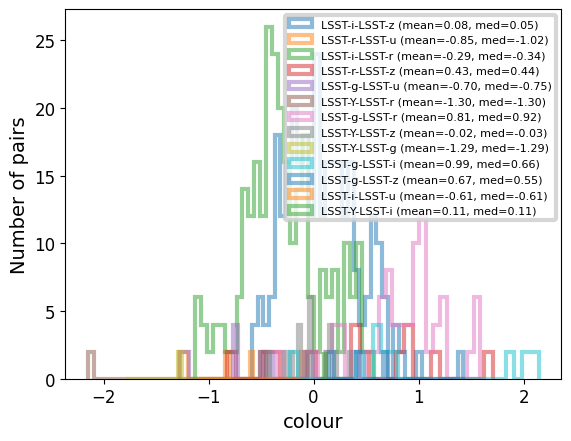

In [27]:
for c in df_colours.colour.unique():
    sel = df_colours[
        (df_colours.colour == c) & 
        (df_colours.SNR1 > 5) & 
        (df_colours.SNR2 > 5)
    ]
    if len(sel) == 0:
        continue
    
    mean_val = sel.mag_diff.mean()
    median_val = sel.mag_diff.median()
    
    # histogram
    plt.hist(sel.mag_diff, bins=30, alpha=0.5, label=f"{c} (mean={mean_val:.2f}, med={median_val:.2f})", histtype='step')
    
    # print colours
    # print(c)
    # print('mean',round(mean_val,1))
    # print('median',round(median_val,1))

plt.xlabel("colour")
plt.ylabel("Number of pairs")
plt.legend(fontsize=8)


In [28]:
df_colours_broker = df_colours[(df_colours.SNR1 > 5) & (df_colours.SNR2 > 5)]
for mod in df_colours_broker.model.unique():
    sel = df_colours_broker[df_colours_broker.model == mod]
    print(f"{mod} Min-max colours from KNe: {sel.mag_diff.min():.1f} {sel.mag_diff.max():.1f}")

Kasen Min-max colours from KNe: -2.1 1.7
Bulla Min-max colours from KNe: -1.3 2.1


Kasen LSST-i-LSST-r mean=-0.22, std=0.46, median=-0.24
Bulla LSST-i-LSST-r mean=-0.34, std=0.27, median=-0.34


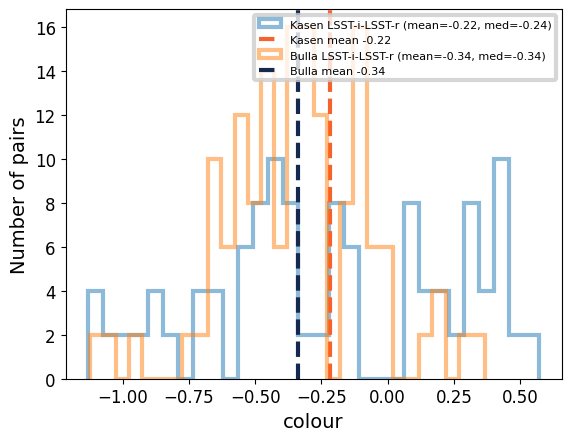

In [29]:
# Only i-r
c = 'LSST-i-LSST-r'
for mod in df_colours_broker.model.unique():
    sel = df_colours[
        (df_colours.colour == c) & 
        (df_colours.SNR1 > 5) & 
        (df_colours.SNR2 > 5) & (df_colours.model == mod)
    ]

    mean_val = sel.mag_diff.mean()
    std_val = sel.mag_diff.std()
    median_val = sel.mag_diff.median()

    # histogram
    plt.hist(sel.mag_diff, bins=30, alpha=0.5, label=f"{mod} {c} (mean={mean_val:.2f}, med={median_val:.2f})", histtype='step')
    plt.axvline(mean_val, color=au.dic_KN_models_colors[mod], linestyle='--', label=f"{mod} mean {mean_val:.2f}")
    print(f"{mod} {c} mean={mean_val:.2f}, std={std_val:.2f}, median={median_val:.2f}")

plt.xlabel("colour")
plt.ylabel("Number of pairs")
plt.legend(fontsize=8)


## Rate of decline

LSST-r median 0.4 +- 0.3
LSST-Y median 0.3 +- 0.5
LSST-i median 0.3 +- 0.4
LSST-u median nan +- nan
LSST-z median 0.2 +- 0.4
LSST-g median 1.0 +- 0.4


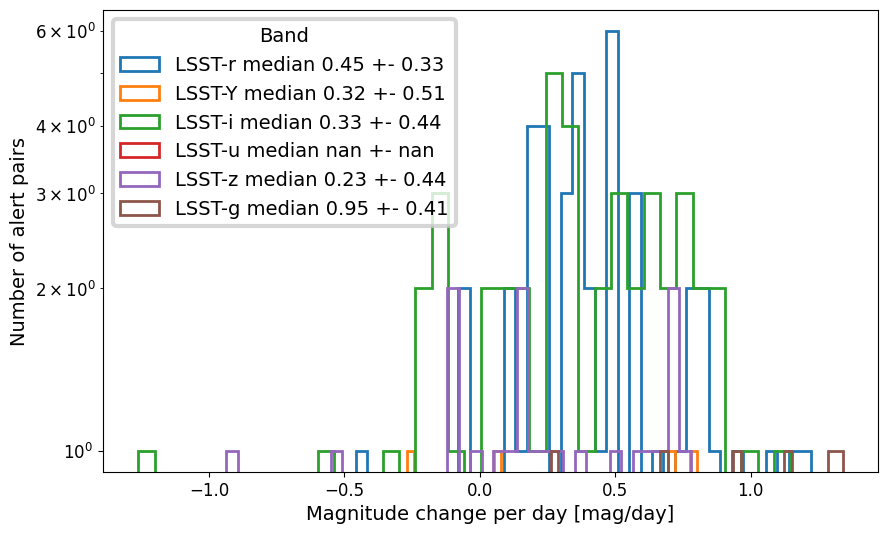

In [30]:
# get all the SNR>5 alerts
df_snr = df_phot[df_phot["SNR"] > 5].copy()
# sort by SNID and BAND
df_snr = df_snr.sort_values(["SNID", "BAND", "MJD"])

# differences
df_snr["dm"] = df_snr.groupby(["SNID", "BAND"])["magnitude"].diff()
df_snr["dt"] = df_snr.groupby(["SNID", "BAND"])["MJD"].diff()

# only compute rate if dt > 1
df_snr["rate_mag_per_day"] = df_snr["dm"].where(df_snr["dt"] > 1) / df_snr["dt"]



plt.figure(figsize=(10,6))

for band in bands:
    sel = df_snr[df_snr["BAND"] == band]
    plt.hist(
        sel["rate_mag_per_day"].dropna(),
        bins=40,
        histtype="step",
        label=f"{band} median {sel['rate_mag_per_day'].mean():.2f} +- {sel['rate_mag_per_day'].std():.2f}",
        linewidth=2
    )
    print(f"{band} median {sel['rate_mag_per_day'].mean():.1f} +- {sel['rate_mag_per_day'].std():.1f}")

plt.xlabel("Magnitude change per day [mag/day]")
plt.ylabel("Number of alert pairs")
plt.yscale("log")
plt.legend(title="Band")
plt.show()



Kasen median 0.3 +- 0.4
Bulla median 0.6 +- 0.4


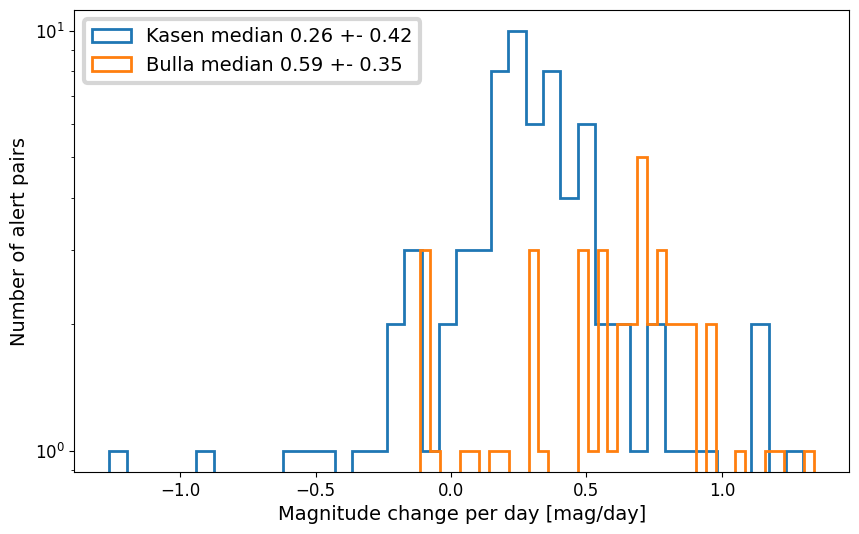

In [31]:
# no band distinction

# get all the SNR>5 alerts
df_snr = df_phot[df_phot["SNR"] > 5].copy()
# sort by SNID and BAND
df_snr = df_snr.sort_values(["SNID", "BAND", "MJD"])

# differences
df_snr["dm"] = df_snr.groupby(["SNID", "BAND"])["magnitude"].diff()
df_snr["dt"] = df_snr.groupby(["SNID", "BAND"])["MJD"].diff()

# only compute rate if dt > 1
df_snr["rate_mag_per_day"] = df_snr["dm"].where(df_snr["dt"] > 1) / df_snr["dt"]

df_snr['model'] = df_snr['SNID'].apply(lambda x: x.split('_')[1] if '_' in x else 'Unknown')

plt.figure(figsize=(10,6))

for mod in df_snr.model.unique():
    sel = df_snr[df_snr["model"] == mod]
    plt.hist(
        sel["rate_mag_per_day"].dropna(),
        bins=40,
        histtype="step",
        label=f"{mod} median {sel['rate_mag_per_day'].mean():.2f} +- {sel['rate_mag_per_day'].std():.2f}",
        linewidth=2
    )
    print(f"{mod} median {sel['rate_mag_per_day'].mean():.1f} +- {sel['rate_mag_per_day'].std():.1f}")

plt.xlabel("Magnitude change per day [mag/day]")
plt.ylabel("Number of alert pairs")
plt.yscale("log")
plt.legend()
plt.show()



Kasen LSST-r: median=0.35, std=0.24, N=31
Kasen LSST-Y: median=-0.27, std=nan, N=1
Kasen LSST-i: median=0.25, std=0.45, N=29
Kasen LSST-z: median=0.13, std=0.47, N=10
Kasen LSST-g: median=0.96, std=0.41, N=5
Bulla LSST-r: median=0.75, std=0.35, N=14
Bulla LSST-Y: median=0.70, std=0.40, N=3
Bulla LSST-i: median=0.68, std=0.30, N=18
Bulla LSST-z: median=0.56, std=0.33, N=10
Bulla LSST-g: median=1.34, std=nan, N=1


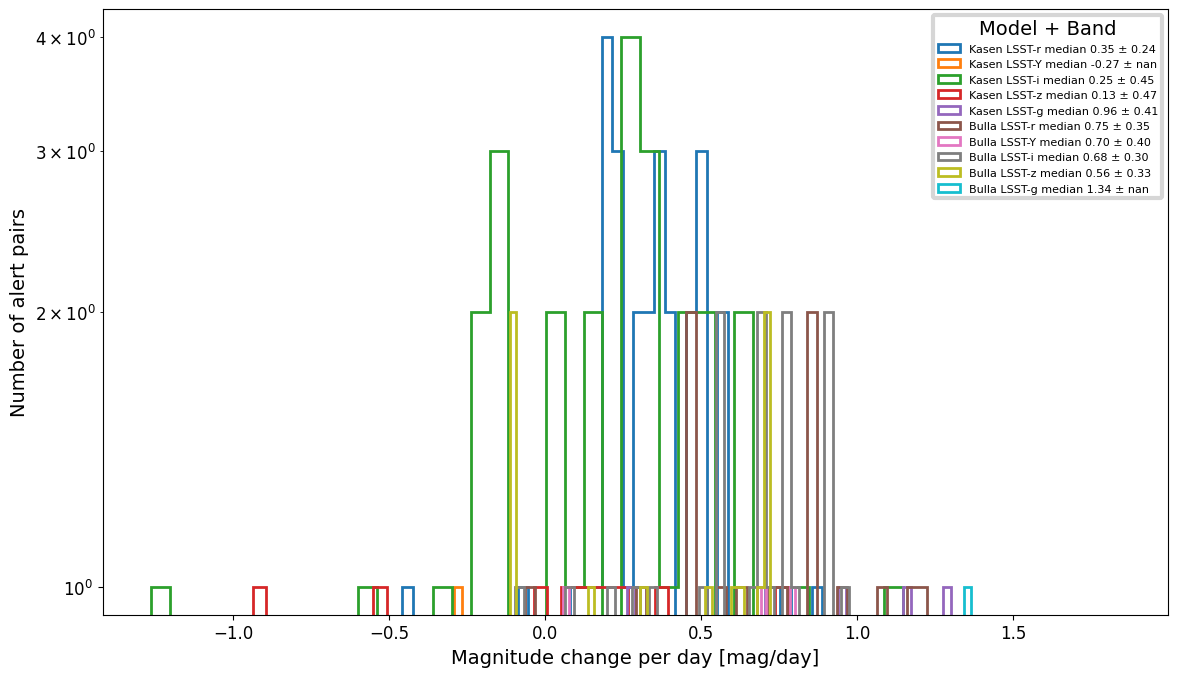

In [32]:
import matplotlib.pyplot as plt

# get all the SNR>5 alerts
df_snr = df_phot[df_phot["SNR"] > 5].copy()
df_snr = df_snr.sort_values(["SNID", "BAND", "MJD"])

# compute differences within each SNID × BAND
df_snr["dm"] = df_snr.groupby(["SNID", "BAND"])["magnitude"].diff()
df_snr["dt"] = df_snr.groupby(["SNID", "BAND"])["MJD"].diff()

# rate, only if dt > 1
df_snr["rate_mag_per_day"] = df_snr["dm"].where(df_snr["dt"] > 1) / df_snr["dt"]

# extract model name from SNID (assumes format like "123_Bulla")
df_snr["model"] = df_snr["SNID"].apply(lambda x: x.split("_")[1] if "_" in x else "Unknown")

# plot
plt.figure(figsize=(12,7))

for mod in df_snr["model"].unique():
    for band in bands:
        sel = df_snr[(df_snr["BAND"] == band) & (df_snr["model"] == mod)]["rate_mag_per_day"].dropna()
        if len(sel) == 0:
            continue

        median_val = sel.median()
        std_val = sel.std()

        plt.hist(
            sel,
            bins=40,
            histtype="step",
            linewidth=2,
            label=f"{mod} {band} median {median_val:.2f} ± {std_val:.2f}"
        )
        print(f"{mod} {band}: median={median_val:.2f}, std={std_val:.2f}, N={len(sel)}")

plt.xlabel("Magnitude change per day [mag/day]")
plt.ylabel("Number of alert pairs")
plt.yscale("log")
plt.legend(fontsize=8, title="Model + Band")
plt.tight_layout()
plt.show()


# Light-curve examples

In [74]:
mpl.rcParams["font.size"] = 14            # default text (tick labels, legend, etc.)
mpl.rcParams["axes.titlesize"] = 14       # title font size
mpl.rcParams["axes.labelsize"] = 14       # x and y labels font size
mpl.rcParams["legend.fontsize"] = 12      # legend
mpl.rcParams["xtick.labelsize"] = 12      # x tick labels
mpl.rcParams["ytick.labelsize"] = 12      # y tick labels
mpl.rcParams["legend.fontsize"] = "medium"
mpl.rcParams["figure.titlesize"] = "large"
mpl.rcParams["lines.linewidth"] = 3
mpl.rcParams["patch.linewidth"] = 3 



dic_band_colors = {
    'LSST-u': '#6A1B9A',   # slightly darker purple, distinct from blue & teal
    'LSST-g': '#3C8DFF',   # light blue (unchanged)
    'LSST-r': '#15284F',   # dark blue/navy (unchanged)
    'LSST-i': '#E69F00',   # orange (unchanged)
    'LSST-z': '#F5622E',   # reddish-orange (unchanged)
    'LSST-Y': '#FFD600'    # golden yellow, cooler than bright yellow, still high contrast
}

def plot_multiple_lcs_matplotlib(df_phot, df_header, idx_list, inmag=False, convert_date=False, savefig=False, path_plots='.'):
    """Plot multiple full light curves in a 2x4 subplot grid, ordered by redshift"""
    
    # Sort idx_list by redshift
    idx_redshifts = []
    for idx in idx_list:
        sel_header = df_header[df_header.SNID == idx]
        if not sel_header.empty:
            z = sel_header.REDSHIFT_FINAL.values[0]
            idx_redshifts.append((idx, z))
        else:
            idx_redshifts.append((idx, 999))  # Put missing data at the end
    
    # Sort by redshift
    idx_redshifts.sort(key=lambda x: x[1])
    idx_list = [idx for idx, z in idx_redshifts]
    
    n_plots = len(idx_list)
    if n_plots > 8:
        print(f"Warning: {n_plots} objects provided, but only first 8 will be plotted")
        idx_list = idx_list[:8]
    
    # Create 2x4 subplot grid
    fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=True)
    axes = axes.flatten()  # Flatten to 1D array for easier iteration
    
    for plot_idx, idx in enumerate(idx_list):
        ax = axes[plot_idx]
        
        sel_phot = df_phot[df_phot.SNID == idx].copy()
        sel_header = df_header[df_header.SNID == idx]
        
        if sel_phot.empty:
            ax.text(0.5, 0.5, f'No data\nSNID {idx}', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"SNID {idx}")
            continue
        
        if inmag:
            sel_phot = sel_phot[sel_phot["magnitude"] > 0]
        
        bands = sel_phot["BAND"].unique()
        x_col = "TIME" if convert_date else "MJD"
        if convert_date:
            sel_phot["TIME"] = pd.to_datetime(sel_phot["MJD"], unit="D", origin="1858-11-17")
        
        peakmjd = float(sel_header.PEAKMJD.values[0])
        peak_x = pd.to_datetime(peakmjd, unit="D", origin="1858-11-17") if convert_date else peakmjd
        redshift = sel_header.REDSHIFT_FINAL.values[0]
        
        # Plot each band
        for flt in bands:
            sel_flt = sel_phot[sel_phot["BAND"] == flt]
            yvar, yerr = ("magnitude", "magnitude error") if inmag else ("FLUXCAL", "FLUXCALERR")
            
            # SNR bins
            for snr_min, snr_max, marker, alpha in [
                (5, np.inf, "o", 1.0),
                (1, 5, "o", 0.3)
            ]:
                mask = (sel_flt['SNR'] > snr_min) & (sel_flt['SNR'] < snr_max) 
                mask &= (sel_flt['MJD']-peakmjd > -8 ) & (sel_flt['MJD']-peakmjd < 15)
                if len(sel_flt[mask]) > 0:
                    ax.errorbar(
                        sel_flt.loc[mask, x_col],
                        sel_flt.loc[mask, yvar],
                        yerr=sel_flt.loc[mask, yerr],
                        fmt=marker,
                        ms=9,
                        # alpha=alpha,
                        color=dic_band_colors[flt],
                        label=f"{flt}" if plot_idx == 0 else None
                    )
            
            # SNR < 1
            mask = sel_flt['SNR'] < 1
            mask &= (sel_flt['MJD']-peakmjd > -8) & (sel_flt['MJD']-peakmjd < 15)
            if len(sel_flt[mask]) > 0:
                ax.scatter(
                    sel_flt.loc[mask, x_col],
                    sel_flt.loc[mask, yvar],
                    marker="v",
                    # alpha=0.2,
                    s=20,
                    color=dic_band_colors[flt]
                )

        # Plot peak time line
        ax.axvline(peak_x, color="black", linestyle="--",zorder=0)
        
        # Set labels and title
        ax.set_title(f"{idx.split('_')[1]}, z={redshift:.2f}", fontsize=24)
        ax.tick_params(axis="x", rotation=30, labelsize=22)
        ax.tick_params(axis="y", labelsize=22)
        
        # Reduce number of x-axis ticks
        ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=4))
        
        # Y-axis limits
        if inmag:
            all_y = sel_phot["magnitude"]
            ymax = all_y.max() + 1 if all_y.max() < 25 else 26
            ax.set_ylim(ymax, all_y.min() - 1)
        else:
            all_y = sel_phot["FLUXCAL"]
            ax.set_ylim(all_y.min() - 1, all_y.max() + 1)
        
        # X-axis label only for bottom row
        if plot_idx >= 4:  # Changed from 5 to 4 (second row starts at index 4)
            ax.set_xlabel("Date" if convert_date else "MJD", fontsize=22)
        
        # Y-axis label only for leftmost column
        if plot_idx % 4 == 0:  # Changed from 5 to 4 (4 columns now)
            ax.set_ylabel("magnitude" if inmag else "FLUXCAL", fontsize=22)
    
    # Hide unused subplots
    for i in range(len(idx_list), 8):  # Changed from 10 to 8
        axes[i].axis('off')
    
    # Create legend (only if first plot has data)
    if len(idx_list) > 0:
        handles = []
        labels = []
        for band, color in dic_band_colors.items():
            handles.append(plt.Line2D([0], [0], marker='o', color='w', 
                                     markerfacecolor=color, markersize=8))
            labels.append(band)
        
        fig.legend(
            handles, labels,
            loc="center left",
            bbox_to_anchor=(1.0, 0.5),
            fontsize=24,
            title="Filter",
            title_fontsize=24
        )
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.05, hspace=0.6, right=0.95)
    
    if savefig:
        plt.savefig(f"{path_plots}/lc_grid_multiple.png", dpi=150, bbox_inches='tight')
    
    return fig, axes

Selected 10 objects across redshift bins:
          SNID  REDSHIFT_FINAL  z_bin
0  23207_Kasen        0.014741   0.01
1  11554_Kasen        0.023385   0.02
2   1815_Bulla        0.031486   0.03
3  12546_Bulla        0.044221   0.04
4   8965_Bulla        0.050870   0.05
5  23756_Bulla        0.067038   0.06
6  17683_Kasen        0.078472   0.07
7   1506_Kasen        0.085070   0.08
8   8497_Bulla        0.094681   0.09
9  12568_Bulla        0.104578   0.10


(<Figure size 2000x1000 with 8 Axes>,
 array([<Axes: title={'center': 'Kasen, z=0.01'}, ylabel='magnitude'>,
        <Axes: title={'center': 'Kasen, z=0.02'}>,
        <Axes: title={'center': 'Bulla, z=0.03'}>,
        <Axes: title={'center': 'Bulla, z=0.04'}>,
        <Axes: title={'center': 'Bulla, z=0.05'}, xlabel='Date', ylabel='magnitude'>,
        <Axes: title={'center': 'Bulla, z=0.07'}, xlabel='Date'>,
        <Axes: title={'center': 'Kasen, z=0.08'}, xlabel='Date'>,
        <Axes: title={'center': 'Kasen, z=0.09'}, xlabel='Date'>],
       dtype=object))

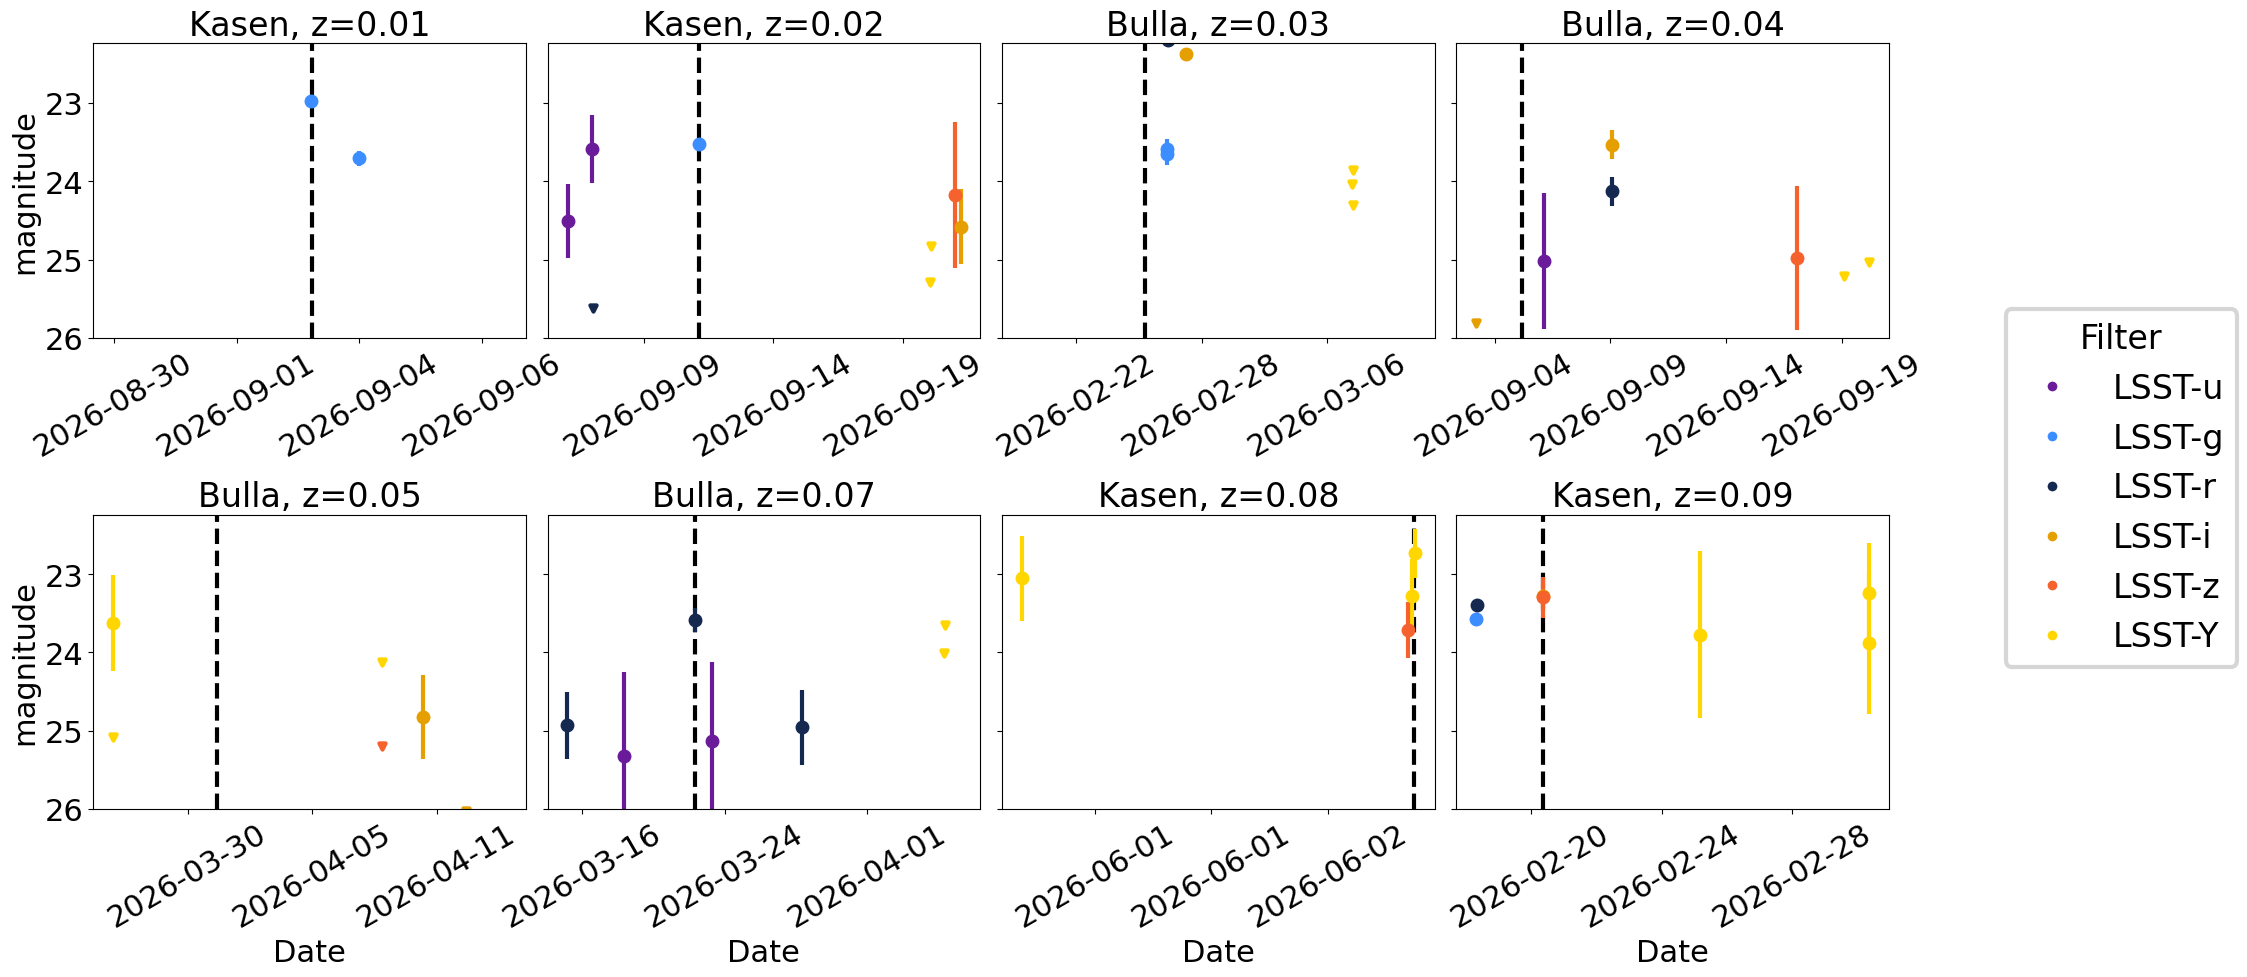

In [75]:
import numpy as np

idxs = df_header['SNID'].unique()

# Get redshifts for these SNIDs
snid_redshift = df_header[df_header['SNID'].isin(idxs)][['SNID', 'REDSHIFT_FINAL']].drop_duplicates()

# Create redshift bins
snid_redshift['z_bin'] = (snid_redshift['REDSHIFT_FINAL'] // 0.01) * 0.01

# avoid some messy light-curves
snid_avoid = ["4157_Bulla","24462_Bulla","20390_Bulla",\
    "28812_Bulla","3112_Kasen","14869_Bulla","11665_Kasen","13621_Kasen","5753_Kasen","15159_Bulla","8335_Bulla","13496_Kasen","14861_Kasen","18372_Bulla","19537_Kasen","6563_Kasen","6320_Kasen","18658_Kasen","15995_Kasen","15995_Bulla","9871_Bulla","23085_Kasen","2659_Bulla","23085_Bulla","11396_Bulla","2848_Bulla"]
snid_redshift = snid_redshift[~snid_redshift['SNID'].isin(snid_avoid)]

# Select only light-curves with more than X points
snid_counts = df_phot[df_phot.SNR>2].groupby('SNID').count()['MJD'].reset_index()
snid_counts = snid_counts[snid_counts['MJD'] > 1]
snid_redshift = snid_redshift[snid_redshift['SNID'].isin(snid_counts['SNID'])]

# Select only lc with vcalid peak
snid_peak = df_header[df_header['PEAKMJD'] > 0][['SNID']]
snid_redshift = snid_redshift[snid_redshift['SNID'].isin(snid_peak['SNID'])]

# Select one random SNID per bin
selected_idx = snid_redshift.groupby('z_bin').sample(n=1, random_state=42).reset_index(drop=True)

# Get just the SNID list
idx_list = selected_idx['SNID'].tolist()

print(f"Selected {len(idx_list)} objects across redshift bins:")
print(selected_idx[['SNID', 'REDSHIFT_FINAL', 'z_bin']])

df_phot[df_phot.SNID.isin(idx_list)]['magnitude'].describe()
plot_multiple_lcs_matplotlib(df_phot, df_header, idx_list=idx_list, inmag=True, convert_date=True, savefig=True, path_plots=path_plots)